In [23]:
import numpy as np
import numpy as np
import pandas as pd
import loadData
import monteCarloClass
import time

In [24]:
# Publication-ready plot configuration
import matplotlib.pyplot as plt
import matplotlib as mpl

# Font sizes
FONT_SIZE_LABEL = 18  # Axis labels and tick labels
FONT_SIZE_TITLE = 20  # Plot titles
FONT_SIZE_LEGEND = 18  # Legend text

# Configure matplotlib parameters globally
plt.rcParams.update({
    # Font sizes
    'font.size': FONT_SIZE_LABEL,          # Base font size
    'axes.labelsize': FONT_SIZE_LABEL,     # X and Y axis labels
    'axes.titlesize': FONT_SIZE_TITLE,     # Subplot titles
    'xtick.labelsize': FONT_SIZE_LABEL,    # X tick labels
    'ytick.labelsize': FONT_SIZE_LABEL,    # Y tick labels
    'legend.fontsize': FONT_SIZE_LEGEND,   # Legend
    
    # Font family
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    
    # Line widths
    'axes.linewidth': 1.5,                 # Axis border width
    'grid.linewidth': 1.0,                 # Grid line width
    'lines.linewidth': 2.0,                # Plot line width
    'lines.markersize': 8,                 # Default marker size
    
    # Tick parameters
    'xtick.major.width': 1.5,              # X tick width
    'ytick.major.width': 1.5,              # Y tick width
    'xtick.major.size': 6,                 # X tick length
    'ytick.major.size': 6,                 # Y tick length
    
    # Legend
    'legend.frameon': True,                # Legend frame
    'legend.framealpha': 0.8,              # Legend transparency
    'legend.edgecolor': 'black',           # Legend border color
    
    # Figure
    'figure.dpi': 100,                     # Display resolution
    'savefig.dpi': 300,                    # Save resolution for publication
    'savefig.bbox': 'tight',               # Tight bounding box
    'savefig.pad_inches': 0.1,             # Padding when saving
    
    # Grid
    'axes.grid': False,                    # No grid by default
    'grid.alpha': 0.3,                     # Grid transparency if enabled
})

print("✓ Publication-ready plot configuration loaded")
print(f"  - Axis labels/ticks: {FONT_SIZE_LABEL}pt")
print(f"  - Titles: {FONT_SIZE_TITLE}pt")
print(f"  - Save resolution: 300 DPI")

✓ Publication-ready plot configuration loaded
  - Axis labels/ticks: 18pt
  - Titles: 20pt
  - Save resolution: 300 DPI


load models


In [25]:
import os
import json
import glob
import pandas as pd
from pathlib import Path

BOXCAR_FITS_DIR = Path("model_fits/boxcarFits")

def load_all_model_results(fits_dir=BOXCAR_FITS_DIR):
    """Load all model-fit JSON files from the boxcar-fits directory."""
    results = []
    
    json_files = glob.glob(str(fits_dir / "**/*.json"), recursive=True)

    
    
    for file_path in json_files:
        print(f"Loading {file_path}")
        
        if "lnd1" in os.path.basename(file_path): # ln1 should be ignored as its the first participant and only half of the data is not corrupt
            continue
        
        # if in filename "all_all", skip
        if "all" in os.path.basename(file_path):
            continue

        if "loglinear" in os.path.basename(file_path).lower():
            continue
        try:
            with open(file_path, 'r') as f:
                result = json.load(f)
            
            # Extract participant ID and model type from filename if not in data
            filename = os.path.basename(file_path)
            parts = filename.replace('.json', '').split('_')
            #print(parts)
            if 'participantID' not in result:
                result['participantID'] = parts[0]
            result['fitParticipantID'] = parts[0]
            result['fitFile'] = file_path

            
            result['modelType'] = parts[1]+"_"+parts[3]
            # if result['modelType'] in "logLinearMismatch_sharedPrior":
            #     continue
            
            if parts[2]=="LapseFree":
                #print("Lapse fixed model, skipping")
                continue
            

            results.append(result)
            
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    return results

# Load all results
all_results = load_all_model_results()
print(f"Loaded {len(all_results)} model fit results")

# Convert to DataFrame for easier analysis
df_results = pd.DataFrame(all_results)

# Guard against duplicate participant/model files while keeping lookup deterministic.
df_results['_is_anon'] = df_results['fitParticipantID'].astype(str).str.match(r'^P\d+$')
df_results = (df_results.sort_values('_is_anon', ascending=False)
                        .drop_duplicates(subset=['participantID', 'modelType'], keep='first')
                        .drop(columns='_is_anon')
                        .reset_index(drop=True))
print(f"Participants: {sorted(df_results['participantID'].unique())}")
print(f"Models: {sorted(df_results['modelType'].unique())}")



Loading model_fits/boxcarFits/sx/sx_switchingFree_LapseFix_sharedPrior_fit.json
Loading model_fits/boxcarFits/sx/sx_fusionOnlyLogNorm_LapseFix_sharedPrior_fit.json
Loading model_fits/boxcarFits/sx/sx_lognorm_LapseFix_sharedPrior_fit.json
Loading model_fits/boxcarFits/mt/mt_lognorm_LapseFix_sharedPrior_fit.json
Loading model_fits/boxcarFits/mt/mt_switchingFree_LapseFix_sharedPrior_fit.json
Loading model_fits/boxcarFits/mt/mt_fusionOnlyLogNorm_LapseFix_sharedPrior_fit.json
Loading model_fits/boxcarFits/mh/mh_switchingFree_LapseFix_sharedPrior_fit.json
Loading model_fits/boxcarFits/mh/mh_lognorm_LapseFix_sharedPrior_fit.json
Loading model_fits/boxcarFits/mh/mh_fusionOnlyLogNorm_LapseFix_sharedPrior_fit.json
Loading model_fits/boxcarFits/dt/dt_switchingFree_LapseFix_sharedPrior_fit.json
Loading model_fits/boxcarFits/dt/dt_fusionOnlyLogNorm_LapseFix_sharedPrior_fit.json
Loading model_fits/boxcarFits/dt/dt_lognorm_LapseFix_sharedPrior_fit.json
Loading model_fits/boxcarFits/oy/oy_switchingFre

In [26]:
# data, dataName = loadData.loadData("as_all.csv")
# intensityVariable = "deltaDurS"
# sensoryVar = "audNoise"
# standardVar = "standardDur"
# conflictVar = "conflictDur"
# #s
# visualStandardVar = "unbiasedVisualStandardDur"
# visualTestVar = "unbiasedVisualTestDur"
# audioStandardVar = "standardDur"
# audioTestVar = "testDurS"
# # Instantiate the Monte Carlo class
# mc_fitter = monteCarloClass.OmerMonteCarlo(data)
# print("Visual test duration range:", data["recordedDurVisualTest"].min(), "to", data["recordedDurVisualTest"].max())
# # fit parameters
# mc_fitter.nStart = 1 # Number of random starts for optimization
# mc_fitter.nSimul = 100 # small number of simulations for quick test
# mc_fitter.optimizationMethod= "bads"  # Use BADS for optimization
# mc_fitter.modelName = "lognorm"  # Set measurement distribution to Gaussian
# mc_fitter.integrationMethod = "analytical"  # Use numerical integration instead of analytical
# mc_fitter.freeP_c = False  # Allow different prior widths for conflict conditions
# mc_fitter.sharedLambda = False  # Use separate lapse rates for each condition
# mc_fitter.dataName = dataName
# #print("t_min, t_max:", mc_fitter.t_min, mc_fitter.t_max)

def _fit_pid_sort_key(pid):
    text = str(pid)
    if text.upper().startswith('P') and text[1:].isdigit():
        return (0, int(text[1:]))   # anonymized P-IDs first, ordered numerically
    return (1, text)                # raw names after, ordered alphabetically (mixed-type safe)


participant_lookup = (
    df_results[['participantID', 'fitParticipantID']]
    .drop_duplicates('participantID')
    .sort_values('fitParticipantID', key=lambda col: col.map(_fit_pid_sort_key))
)
participantIds = participant_lookup['participantID'].tolist()
PARTICIPANT_TO_FIT_ID = dict(zip(participant_lookup['participantID'], participant_lookup['fitParticipantID']))

# Sequential display labels P1..PN in participant order (ignores gaps in the fit IDs).
SEQ_LABELS = {pid: f'P{i+1}' for i, pid in enumerate(participantIds)}


def participant_label(participantID):
    fit_id = str(PARTICIPANT_TO_FIT_ID.get(participantID, participantID))
    if fit_id.upper().startswith('P') and fit_id[1:].isdigit():
        return f'P{int(fit_id[1:])}'
    return fit_id.upper()


def load_participant_data(participantID):
    return loadData.loadData(f'{participantID}_all.csv', verbose=False)


def get_fit_result(participantID, model_name='lognorm', prior_tag='sharedPrior'):
    model_type = f'{model_name}_{prior_tag}'
    rows = df_results[
        (df_results['participantID'] == participantID)
        & (df_results['modelType'] == model_type)
    ]
    if rows.empty:
        fit_id = PARTICIPANT_TO_FIT_ID.get(participantID, participantID)
        raise FileNotFoundError(f'Missing fit for {participantID} ({fit_id}), model={model_type}')
    return rows.iloc[0].to_dict()


modelTypes=sorted(df_results['modelType'].unique())
nParticipants=len(participantIds)
nModels=len(modelTypes)

import fitSaver
import os
participantID="as"
modelType="fusionOnlyLogNorm"

# simulate



 Load data

In [27]:
# import bootstrapperSaveLoad functions
import matplotlib.pyplot as plt
from bootstrapperSaveLoad import saveBootstrappedParams, loadBootstrappedParams
import loadResults
import os
import json
import seaborn as sns

# PLot the posterior per participants

Functions

In [28]:
from scipy.stats import norm

# --- FUSION MODEL IMPLEMENTATION ---
def fusion_estimate(m_a, m_v, sigma_a, sigma_v):
    """Bayesian optimal integration of auditory and visual measurements."""
    # Calculate weights based on reliabilities (inverse variances)
    w_a = 1 / sigma_a**2
    w_v = 1 / sigma_v**2
    # Compute the fused estimate
    fused_estimate = (w_a * m_a + w_v * m_v) / (w_a + w_v)
    return fused_estimate

# --- CAUSAL INFERENCE MODEL IMPLEMENTATION ---
def p_single(m,sigma,t_min,t_max):
    """p(m | C=2) and Gaussian measurement noise N(m; y, sigma^2)."""
    hi_cdf= norm.cdf((t_max - m) /sigma)
    lo_cdf=norm.cdf((t_min-m)/sigma)
    return (hi_cdf-lo_cdf)/(t_max-t_min)

# Causal inference model for duration estimation
def L_C1(m_a,m_v,sigma_a,sigma_v,t_min,t_max):
    sigma_c_sq = (sigma_a**2 * sigma_v**2) / (sigma_a**2 + sigma_v**2)
    sigma_c = np.sqrt(sigma_c_sq)
    mu_c = (m_a / sigma_a**2 + m_v / sigma_v**2) / (1 / sigma_a**2 + 1 / sigma_v**2)

    hi_cdf = norm.cdf((t_max-mu_c)/sigma_c)
    lo_cdf = norm.cdf((t_min-mu_c)/sigma_c)
    
    expo = np.exp(-(m_a-m_v)**2/(2*(sigma_a**2+sigma_v**2)))
    
    prior = 1/(t_max-t_min)
    return prior * sigma_c/np.sqrt(sigma_a**2 * sigma_v**2) * (hi_cdf-lo_cdf) * expo

def L_C1_no_prior(m_a, m_v, sigma_a, sigma_v):
    """Likelihood of common source without prior and bounding."""
    sigma_c_sq = (sigma_a**2 * sigma_v**2) / (sigma_a**2 + sigma_v**2)
    sigma_c = np.sqrt(sigma_c_sq)
    mu_c = (m_a / sigma_a**2 + m_v / sigma_v**2) / (1 / sigma_a**2 + 1 / sigma_v**2)
    
    expo = np.exp(-(m_a - m_v)**2 / (2 * (sigma_a**2 + sigma_v**2)))
    
    return sigma_c / np.sqrt(sigma_a**2 * sigma_v**2) * expo



def L_C2(m_a,m_v,sigma_a,sigma_v,t_min,t_max):
    """ Likelihood of separate sources: product of two marginal likelihoods 
        two integral over two hidden duration y_a y_v"""
    return p_single(m_a,sigma_a,t_min,t_max) * p_single(m_v,sigma_v,t_min,t_max)


def L_C2_no_prior(m_a, m_v, sigma_a, sigma_v):
    """Likelihood of separate sources without prior and bounding."""
    return norm.pdf(m_a, loc=m_a, scale=sigma_a) * norm.pdf(m_v, loc=m_v, scale=sigma_v)

def posterior_C1(m_a,m_v,sigma_a,sigma_v,p_c,t_min,t_max):
    """ Posterior probability of common cause P(C=1 | m_a,m_v) """
    # Likelihoods under each causal structure
    L1 = L_C1(m_a,m_v,sigma_a,sigma_v,t_min,t_max)
    L2 = L_C2(m_a,m_v,sigma_a,sigma_v,t_min,t_max)


    post_C1= (L1 * p_c) / (L1 * p_c + L2 * (1 - p_c))
    return post_C1

    # # Unnormalized posteriors
    # post_C1_unnorm = L1 * p_c
    # post_C2_unnorm = L2 * (1 - p_c)
    # # Normalization constant
    # norm_const = post_C1_unnorm + post_C2_unnorm
    

    # # Posterior probabilities
    # post_C1 = post_C1_unnorm / norm_const
    # return post_C1


Plot posterior commons liklihoods of common and separate sources

In [29]:
FONT_SIZE_LABEL

18

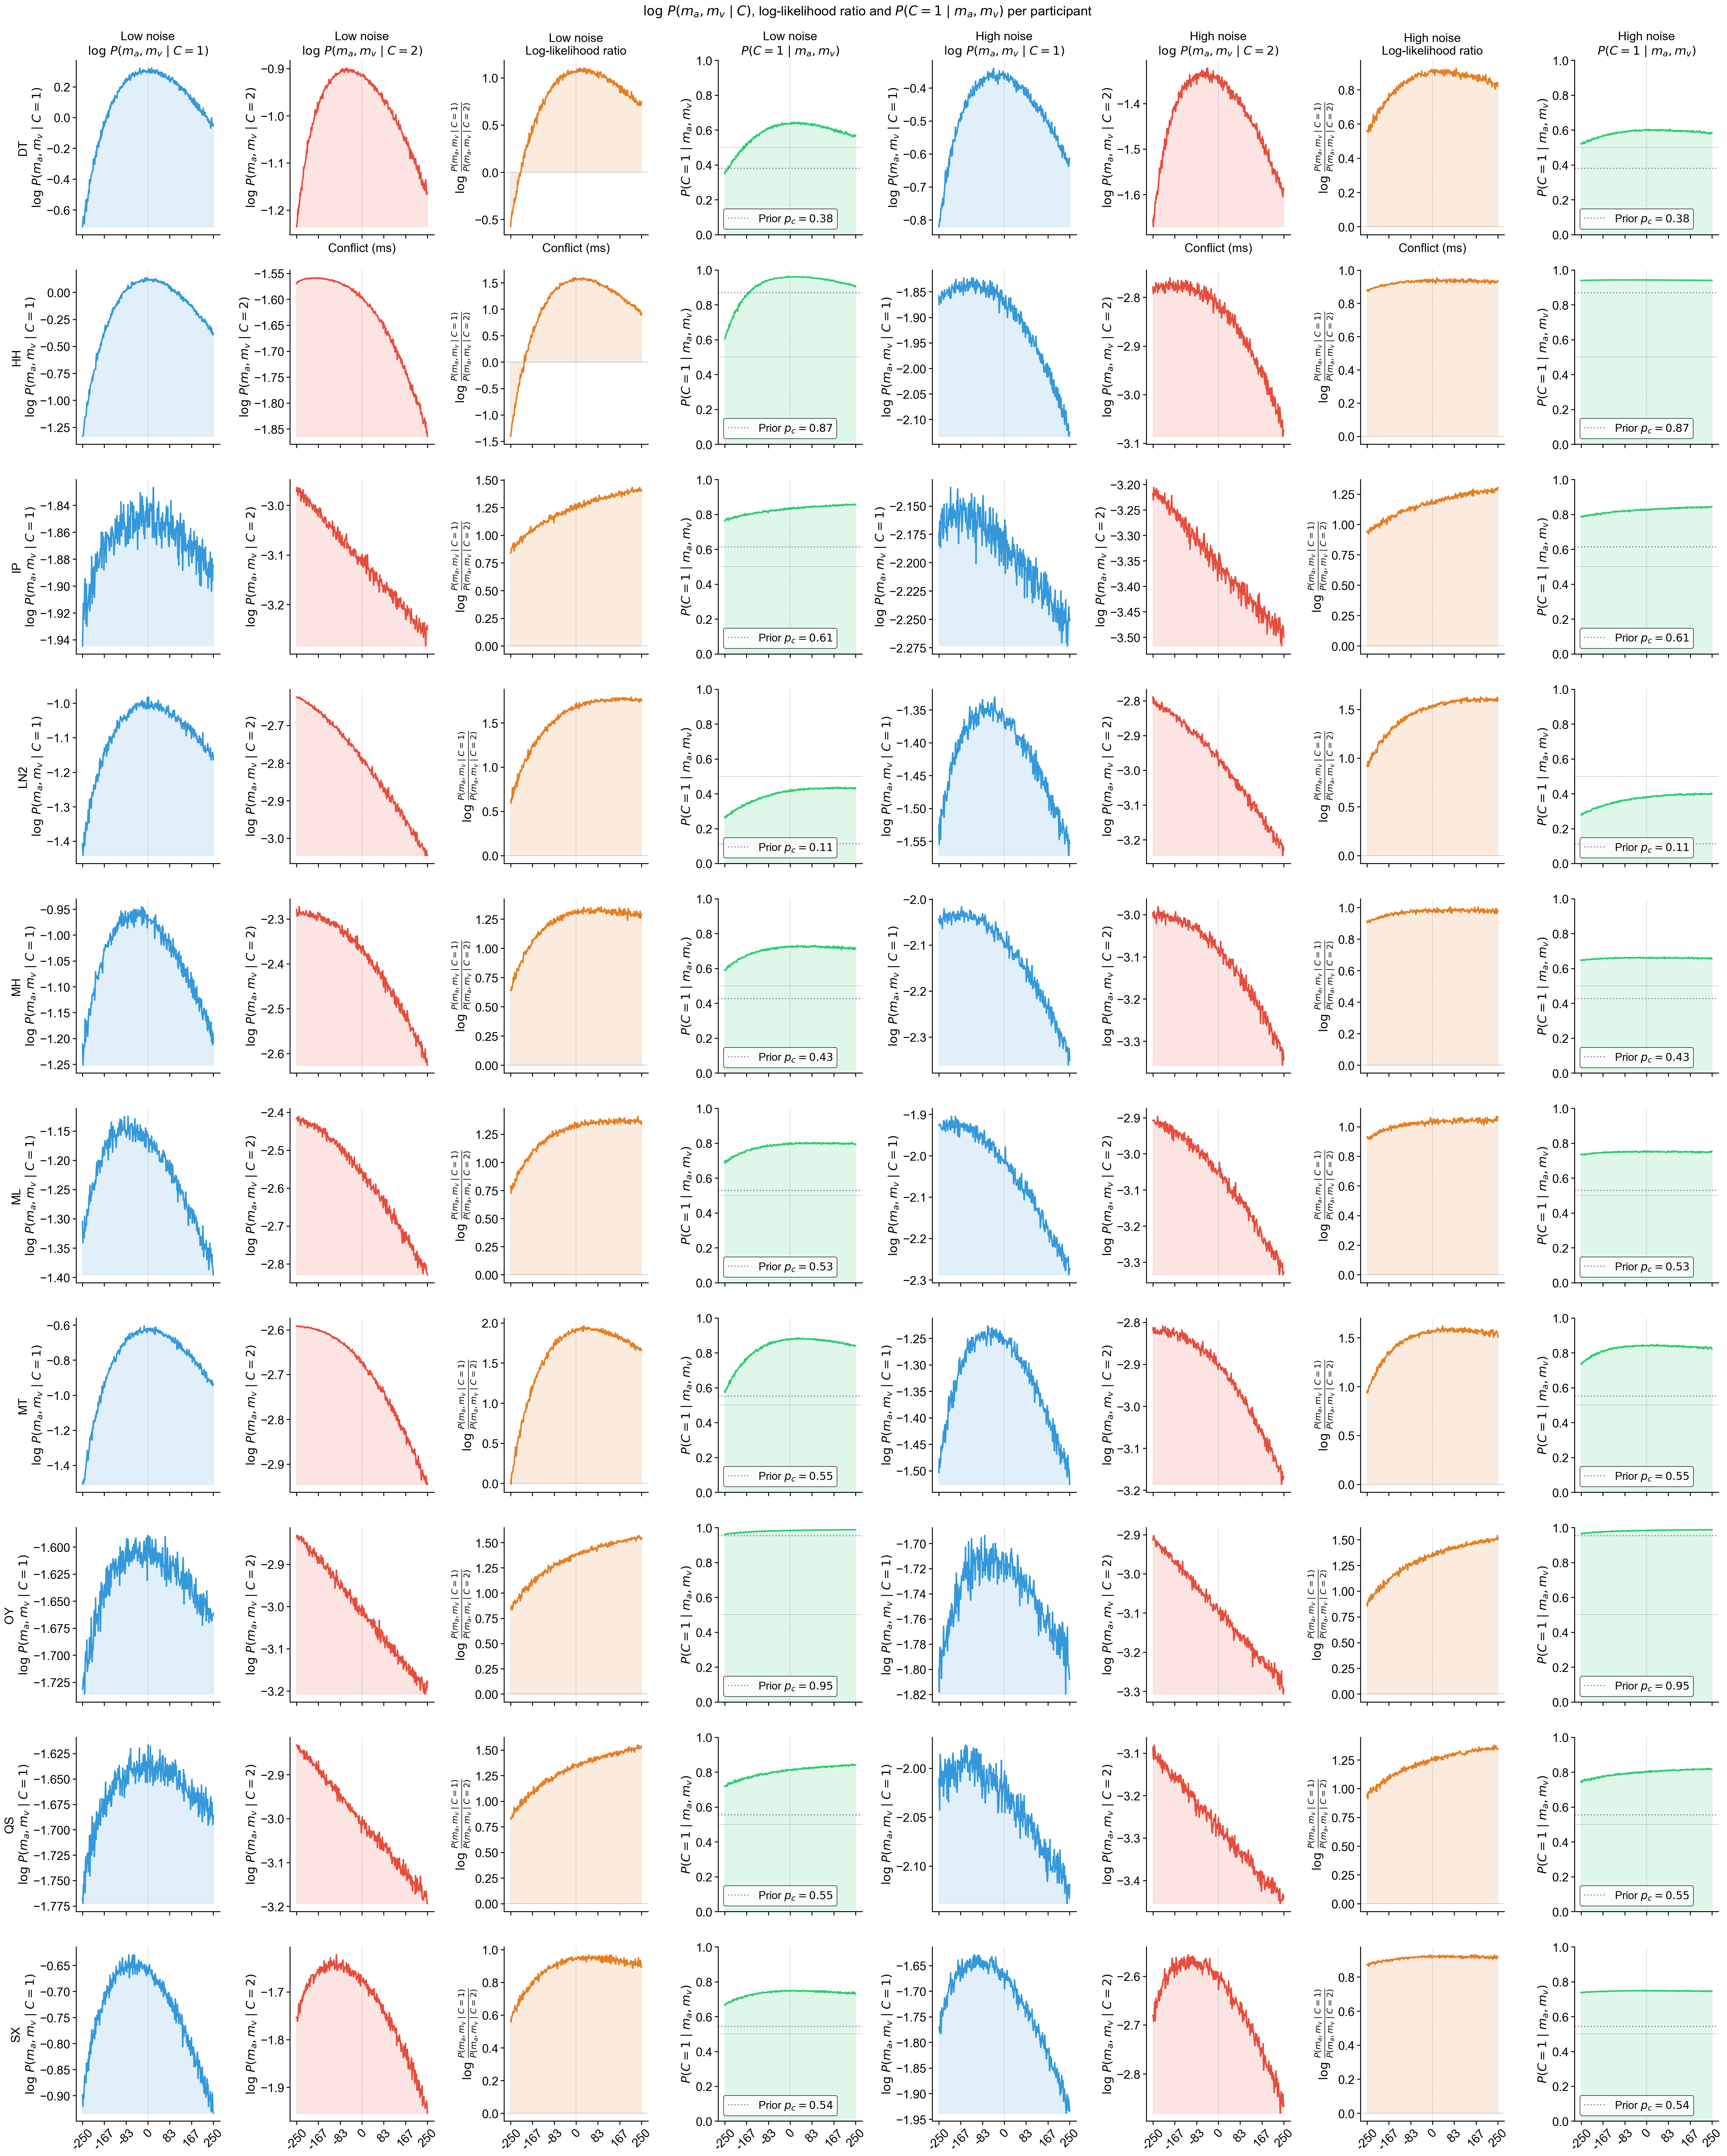

In [30]:
FONTSIZE_MP = 20   # font size for multi-participant figure

def plot_likelihood_components(sigma_a=0.3, sigma_v=0.3, p_c=0.5, t_min=0.1, t_max=3,
                               measurement="log-space", nSimul=2000, axes=None, show_plot=True,
                               show_titles=True, show_xticks=True):
    """
    Plot log P(m_a,m_v|C=1), log P(m_a,m_v|C=2), log-likelihood ratio, and posterior
    P(C=1|m_a,m_v) across conflict levels.  Expects axes with 4 subplots.
    """
    conflicts = np.linspace(-0.25, +0.25, 300)
    L1_means, L2_means, post_c_means, log_ratio_means = [], [], [], []

    S_a_s = 0.5
    for conflict in conflicts:
        S_v_s = S_a_s + conflict
        if measurement == "log-space" and S_v_s <= 0:
            L1_means.append(np.nan); L2_means.append(np.nan)
            log_ratio_means.append(np.nan); post_c_means.append(np.nan)
            continue

        if measurement == "log-space":
            m_a_s = np.random.normal(np.log(S_a_s), sigma_a, nSimul)
            m_v_s = np.random.normal(np.log(S_v_s), sigma_v, nSimul)
            t_min_use, t_max_use = np.log(t_min), np.log(t_max)
        else:
            m_a_s = np.random.normal(S_a_s, sigma_a, nSimul)
            m_v_s = np.random.normal(S_v_s, sigma_v, nSimul)
            t_min_use, t_max_use = t_min, t_max

        L1 = L_C1(m_a_s, m_v_s, sigma_a, sigma_v, t_min_use, t_max_use)
        L2 = L_C2(m_a_s, m_v_s, sigma_a, sigma_v, t_min_use, t_max_use)
        L1_means.append(np.mean(L1))
        L2_means.append(np.mean(L2))

        post_c1 = posterior_C1(m_a_s, m_v_s, sigma_a, sigma_v, p_c, t_min_use, t_max_use)
        post_c_means.append(np.mean(post_c1))

        with np.errstate(divide='ignore', invalid='ignore'):
            log_ratio_means.append(np.mean(np.log(L1) - np.log(L2)))

    # Colours — same as manuscript figure
    c1_col, c2_col, ratio_col, post_col, prior_col = (
        '#3498db', '#e74c3c', '#e67e22', '#2ecc71', '#9b59b6')

    if axes is None and show_plot:
        fig, axes = plt.subplots(1, 4, figsize=(24, 5))
        plt.subplots_adjust(wspace=0.4)
        created_fig = True
    else:
        created_fig = False

    if show_plot:
        conflicts_ms = np.array(conflicts) * 1000
        log_L1_means = np.log(L1_means)
        log_L2_means = np.log(L2_means)

        # --- Column 0: log P(m_a, m_v | C=1) ---
        axes[0].plot(conflicts_ms, log_L1_means, color=c1_col, linewidth=2.5)
        axes[0].fill_between(conflicts_ms, np.nanmin(log_L1_means), log_L1_means,
                             alpha=0.15, color=c1_col)
        axes[0].axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
        axes[0].set_ylabel(r'$\log\, P(m_a, m_v \mid C{=}1)$', fontsize=FONTSIZE_MP)
        if show_titles:
            axes[0].set_title(r'$\log\, P(m_a, m_v \mid C{=}1)$',
                              fontsize=FONTSIZE_MP, pad=10)
        axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)
        axes[0].tick_params(labelsize=FONTSIZE_MP)

        # --- Column 1: log P(m_a, m_v | C=2) ---
        axes[1].plot(conflicts_ms, log_L2_means, color=c2_col, linewidth=2.5)
        axes[1].fill_between(conflicts_ms, np.nanmin(log_L2_means), log_L2_means,
                             alpha=0.15, color=c2_col)
        axes[1].axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
        axes[1].set_ylabel(r'$\log\, P(m_a, m_v \mid C{=}2)$', fontsize=FONTSIZE_MP)
        if show_titles:
            axes[1].set_title(r'$\log\, P(m_a, m_v \mid C{=}2)$',
                              fontsize=FONTSIZE_MP, pad=10)
        axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
        axes[1].tick_params(labelsize=FONTSIZE_MP)

        # --- Column 2: log-likelihood ratio ---
        axes[2].plot(conflicts_ms, log_ratio_means, color=ratio_col, linewidth=2.5)
        axes[2].fill_between(conflicts_ms, 0, log_ratio_means, alpha=0.15, color=ratio_col)
        axes[2].axhline(0, color='gray', ls='-', lw=0.8, alpha=0.5)
        axes[2].axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
        axes[2].set_ylabel(r'$\log\,\frac{P(m_a, m_v \mid C{=}1)}{P(m_a, m_v \mid C{=}2)}$',
                           fontsize=FONTSIZE_MP)
        if show_titles:
            axes[2].set_title('Log-likelihood ratio', fontsize=FONTSIZE_MP, pad=10)
        axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)
        axes[2].tick_params(labelsize=FONTSIZE_MP)

        # --- Column 3: posterior P(C=1 | m_a, m_v) ---
        axes[3].plot(conflicts_ms, post_c_means, color=post_col, linewidth=2.5)
        axes[3].fill_between(conflicts_ms, 0, post_c_means, alpha=0.15, color=post_col)
        axes[3].axhline(0.5, color='gray', ls='-', lw=0.8, alpha=0.5)
        axes[3].axhline(p_c, color=prior_col, ls=':', lw=2, alpha=0.8,
                        label=f'Prior $p_c = {p_c:.2f}$')
        axes[3].axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
        axes[3].set_ylabel(r'$P(C{=}1 \mid m_a, m_v)$', fontsize=FONTSIZE_MP)
        if show_titles:
            axes[3].set_title(r'$P(C{=}1 \mid m_a, m_v)$', fontsize=FONTSIZE_MP, pad=10)
        axes[3].set_ylim([0, 1])
        axes[3].legend(fontsize=FONTSIZE_MP - 2, loc='lower left')
        axes[3].spines['top'].set_visible(False); axes[3].spines['right'].set_visible(False)
        axes[3].tick_params(labelsize=FONTSIZE_MP)

        # x-axis ticks
        x_ticks = [-250, -167, -83, 0, 83, 167, 250]
        if show_xticks:
            for ax in axes:
                ax.set_xticks(x_ticks)
                ax.set_xticklabels([str(t) for t in x_ticks],
                                   fontsize=FONTSIZE_MP, rotation=45)
        else:
            for ax in axes:
                ax.set_xticks(x_ticks)
                ax.set_xticklabels([])

        if created_fig:
            plt.tight_layout()

    return conflicts, L1_means, L2_means, post_c_means


def plotPosteriorsPerSubj(participantIds, modelTypes, parameterToPLot="mu"):
    lenSubjs = len(participantIds)
    nNoiseLevels = 2   # low and high noise
    nPlotsPerNoise = 4  # log P(m|C=1), log P(m|C=2), ratio, posterior

    fig, axes = plt.subplots(
        lenSubjs, nNoiseLevels * nPlotsPerNoise,
        figsize=(5 * nNoiseLevels * nPlotsPerNoise, 5 * lenSubjs),
        dpi=150, squeeze=False
    )
    plt.subplots_adjust(hspace=0.35, wspace=0.35, top=0.95)

    noise_labels = {0.1: "Low noise", 1.2: "High noise"}

    for pNum, participantID in enumerate(participantIds):
        for j, audioNoiseLevel in enumerate([0.1, 1.2]):
            data, dataName = load_participant_data(participantID)
            mc_fitter = monteCarloClass.OmerMonteCarlo(data)
            mc_fitter.modelName = "lognorm"
            mc_fitter.freeP_c = False
            mc_fitter.sharedLambda = False
            mc_fitter.dataName = dataName
            res = get_fit_result(participantID, model_name=mc_fitter.modelName)
            mc_fitter.modelFit = res['fittedParams']

            sigma_v = mc_fitter.modelFit[2]
            p_c     = mc_fitter.modelFit[3]
            sigma_a = mc_fitter.modelFit[1] if audioNoiseLevel == 0.1 else mc_fitter.modelFit[4]

            start_col = j * nPlotsPerNoise
            subplot_axes = [axes[pNum, start_col + k] for k in range(nPlotsPerNoise)]

            first_row = (pNum == 0)
            last_row  = (pNum == lenSubjs - 1)

            plot_likelihood_components(
                sigma_a=sigma_a, sigma_v=sigma_v, p_c=p_c,
                t_min=mc_fitter.data_t_min, t_max=mc_fitter.data_t_max,
                measurement="log-space", nSimul=2000,
                axes=subplot_axes, show_plot=True,
                show_titles=first_row,
                show_xticks=last_row
            )

            # Noise-level label on top of each block (first row only)
            if first_row:
                noise_label = noise_labels[audioNoiseLevel]
                for k in range(nPlotsPerNoise):
                    old = subplot_axes[k].get_title()
                    subplot_axes[k].set_title(
                        f"{noise_label}\n{old}" if old else noise_label,
                        fontsize=FONTSIZE_MP, pad=10
                    )
                subplot_axes[1].set_xlabel('Conflict (ms)', fontsize=FONTSIZE_MP)
                subplot_axes[2].set_xlabel('Conflict (ms)', fontsize=FONTSIZE_MP)

        # Participant label on leftmost y-axis of each row
        current_ylabel = axes[pNum, 0].get_ylabel()
        axes[pNum, 0].set_ylabel(
            f'{participantID.upper()}\n{current_ylabel}', fontsize=FONTSIZE_MP)

    plt.suptitle(r"$\log\,P(m_a, m_v \mid C)$, log-likelihood ratio and $P(C{=}1 \mid m_a, m_v)$ per participant",
                 fontsize=FONTSIZE_MP + 2, y=0.995)
    plt.tight_layout()
    plt.show()

# Run
plotPosteriorsPerSubj(participantIds[1:], modelTypes, parameterToPLot="mu")

**Figure caption (multi-participant version):** Log-likelihood ratio and posterior probability of a common cause as a function of audiovisual duration conflict for each participant. Columns are grouped by auditory noise condition: the left pair shows low noise and the right pair shows high noise. For each condition, the first column displays the log-likelihood ratio $\log\bigl[P(\mathbf{m}\mid C{=}1)\,/\,P(\mathbf{m}\mid C{=}2)\bigr]$, where $\mathbf{m}=(m_a,m_v)$ denotes the auditory and visual measurements; values above zero favour a common-cause interpretation. The second column shows the posterior probability $P(C{=}1 \mid \mathbf{m})$, with the dotted purple line indicating the fitted prior $p_c$. Both quantities are computed via Monte Carlo sampling using participant-specific sensory-noise parameters ($\sigma_a$, $\sigma_v$) and common-cause prior ($p_c$) estimated under the log-normal causal-inference model-averaging strategy.

---

**Figure caption (manuscript, participant DT):** Marginal likelihoods of the measurements and posterior probability of a common cause for an example participant (DT), plotted as a function of audiovisual duration conflict. The top row shows the low-auditory-noise condition; the bottom row shows the high-auditory-noise condition. From left to right: (1) the log marginal likelihood under a common cause, $\log P(m_a, m_v \mid C{=}1)$; (2) the log marginal likelihood under separate causes, $\log P(m_a, m_v \mid C{=}2)$; (3) the log-likelihood ratio $\log\bigl[P(m_a, m_v \mid C{=}1)\,/\,P(m_a, m_v \mid C{=}2)\bigr]$, where values above zero favour a common-cause interpretation; and (4) the posterior probability of a common cause, $P(C{=}1 \mid m_a, m_v)$, with the dotted purple line marking the fitted prior $p_c$. All quantities were computed via Monte Carlo simulation (5 000 samples per conflict level) using participant-specific sensory-noise estimates ($\sigma_a$, $\sigma_v$) and the common-cause prior ($p_c$) obtained from the log-normal causal-inference model-averaging fit. The posterior remains well above 0.5 across all conflict levels for this participant, indicating that this observer's data are consistent with treating the auditory and visual signals as originating from a common source regardless of the imposed conflict. This finding explains why the causal-inference and forced-fusion models produce similar predictions for this participant.

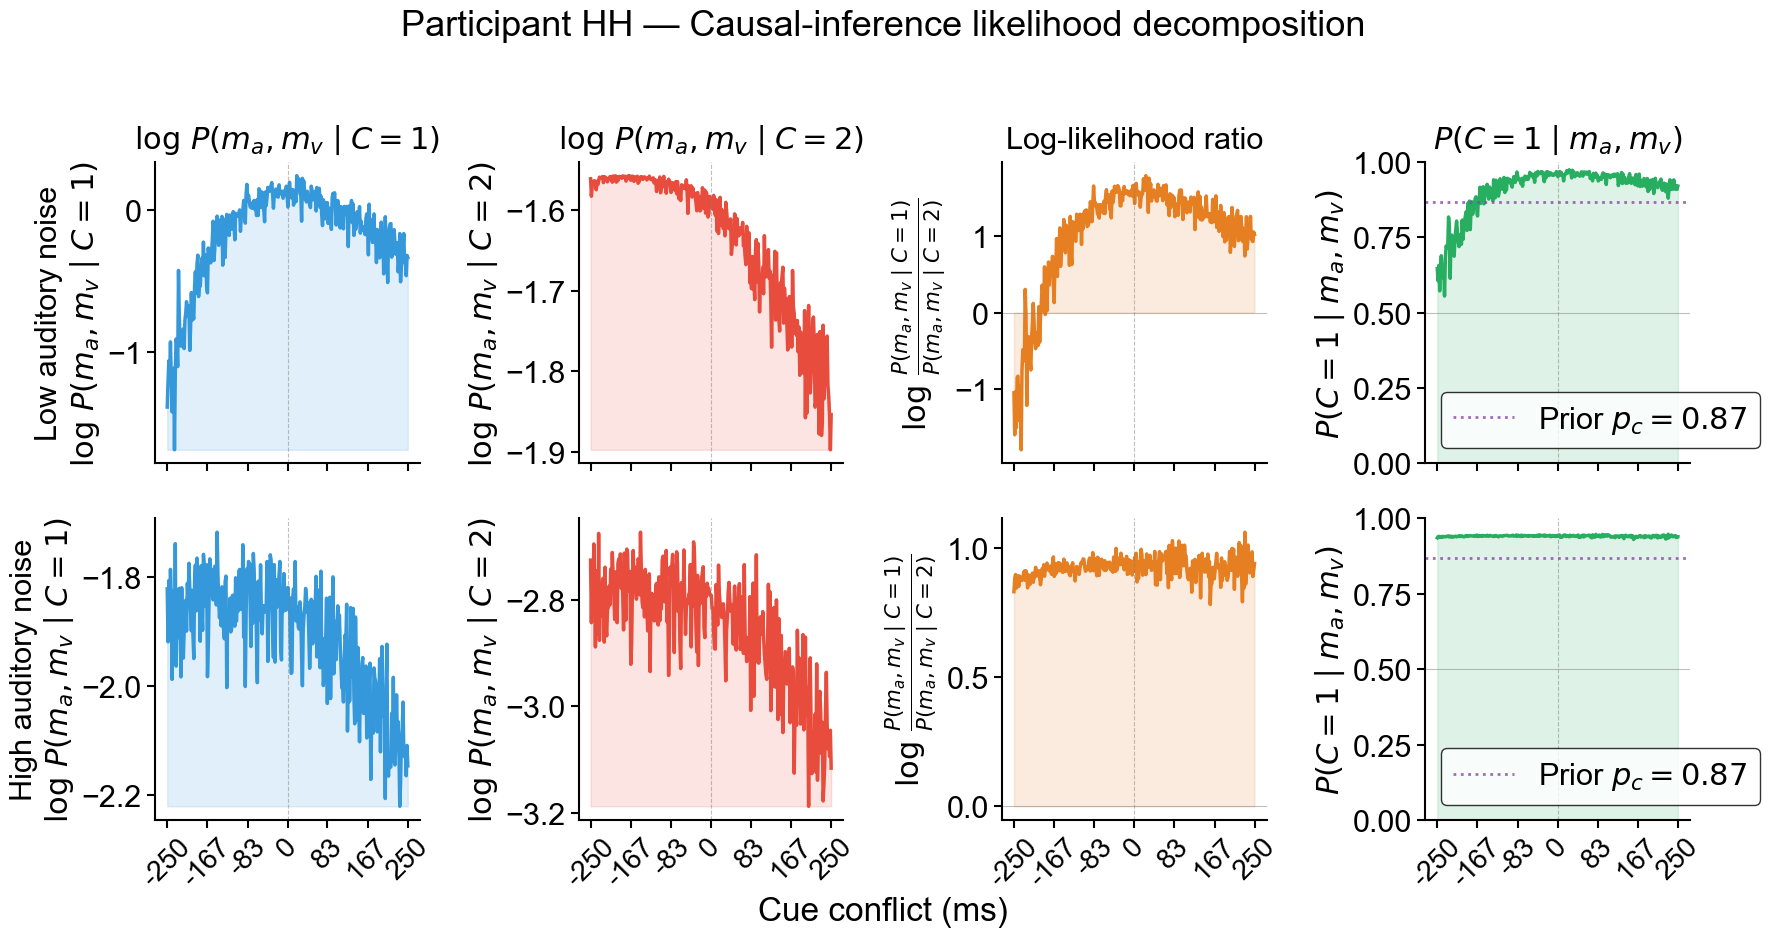

Saved manuscript_posterior_hh.png/.pdf


In [31]:
# Participant DT (index 2) — manuscript figure
# Layout: 2 rows (low noise top, high noise bottom) × 4 columns
# Columns: log P(m_a,m_v|C=1), log P(m_a,m_v|C=2), log-likelihood ratio, posterior P(C=1|m_a,m_v)

import matplotlib.pyplot as plt
import numpy as np

FONTSIZE = 22

def plot_all_four_panels(sigma_a, sigma_v, p_c, t_min, t_max,
                         measurement="log-space", nSimul=5000, axes=None,
                         show_titles=True, show_xlabel=True):
    """
    Plot log P(m_a,m_v|C=1), log P(m_a,m_v|C=2), log-likelihood ratio, and posterior P(C=1|m_a,m_v)
    across conflict levels.  Expects axes with 4 subplots.
    """
    conflicts = np.linspace(-0.25, +0.25, 300)
    L1_means, L2_means, log_ratio_means, post_c_means = [], [], [], []

    S_a_s = 0.5
    for conflict in conflicts:
        S_v_s = S_a_s + conflict
        if measurement == "log-space" and S_v_s <= 0:
            L1_means.append(np.nan); L2_means.append(np.nan)
            log_ratio_means.append(np.nan); post_c_means.append(np.nan)
            continue

        if measurement == "log-space":
            m_a = np.random.normal(np.log(S_a_s), sigma_a, nSimul)
            m_v = np.random.normal(np.log(S_v_s), sigma_v, nSimul)
            t_lo, t_hi = np.log(t_min), np.log(t_max)
        else:
            m_a = np.random.normal(S_a_s, sigma_a, nSimul)
            m_v = np.random.normal(S_v_s, sigma_v, nSimul)
            t_lo, t_hi = t_min, t_max

        l1 = L_C1(m_a, m_v, sigma_a, sigma_v, t_lo, t_hi)
        l2 = L_C2(m_a, m_v, sigma_a, sigma_v, t_lo, t_hi)
        L1_means.append(np.mean(l1))
        L2_means.append(np.mean(l2))

        pc1 = posterior_C1(m_a, m_v, sigma_a, sigma_v, p_c, t_lo, t_hi)
        post_c_means.append(np.mean(pc1))

        with np.errstate(divide='ignore', invalid='ignore'):
            log_ratio_means.append(np.mean(np.log(l1) - np.log(l2)))

    x = np.array(conflicts) * 1000  # convert to ms
    log_L1 = np.log(L1_means)
    log_L2 = np.log(L2_means)

    # Colours
    c1_col, c2_col, ratio_col, post_col, prior_col = (
        '#3498db', '#e74c3c', '#e67e22', '#27ae60', '#8e44ad')

    # --- Column 0: log P(m_a, m_v | C=1) ---
    ax = axes[0]
    ax.plot(x, log_L1, color=c1_col, linewidth=2.5)
    ax.fill_between(x, np.nanmin(log_L1), log_L1, alpha=0.15, color=c1_col)
    ax.axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_ylabel(r'$\log\, P(m_a, m_v \mid C{=}1)$', fontsize=FONTSIZE)
    if show_titles:
        ax.set_title(r'$\log\, P(m_a, m_v \mid C{=}1)$', fontsize=FONTSIZE, pad=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE)

    # --- Column 1: log P(m_a, m_v | C=2) ---
    ax = axes[1]
    ax.plot(x, log_L2, color=c2_col, linewidth=2.5)
    ax.fill_between(x, np.nanmin(log_L2), log_L2, alpha=0.15, color=c2_col)
    ax.axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_ylabel(r'$\log\, P(m_a, m_v \mid C{=}2)$', fontsize=FONTSIZE)
    if show_titles:
        ax.set_title(r'$\log\, P(m_a, m_v \mid C{=}2)$', fontsize=FONTSIZE, pad=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE)

    # --- Column 2: log-likelihood ratio ---
    ax = axes[2]
    ax.plot(x, log_ratio_means, color=ratio_col, linewidth=2.5)
    ax.fill_between(x, 0, log_ratio_means, alpha=0.15, color=ratio_col)
    ax.axhline(0, color='gray', ls='-', lw=0.8, alpha=0.5)
    ax.axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_ylabel(r'$\log\,\frac{P(m_a, m_v \mid C{=}1)}{P(m_a, m_v \mid C{=}2)}$',
                  fontsize=FONTSIZE)
    if show_titles:
        ax.set_title('Log-likelihood ratio', fontsize=FONTSIZE, pad=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE)

    # --- Column 3: posterior P(C=1 | m_a, m_v) ---
    ax = axes[3]
    ax.plot(x, post_c_means, color=post_col, linewidth=2.5)
    ax.fill_between(x, 0, post_c_means, alpha=0.15, color=post_col)
    ax.axhline(0.5, color='gray', ls='-', lw=0.8, alpha=0.5)
    ax.axhline(p_c, color=prior_col, ls=':', lw=2, alpha=0.8,
               label=f'Prior $p_c = {p_c:.2f}$')
    ax.axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_ylabel(r'$P(C{=}1 \mid m_a, m_v)$', fontsize=FONTSIZE)
    if show_titles:
        ax.set_title(r'$P(C{=}1 \mid m_a, m_v)$', fontsize=FONTSIZE, pad=10)
    ax.set_ylim([0, 1])
    ax.legend(fontsize=FONTSIZE , loc='lower left')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE)

    # x-axis ticks
    x_ticks = [-250, -167, -83, 0, 83, 167, 250]
    if show_xlabel:
        for a in axes:
            a.set_xticks(x_ticks)
            a.set_xticklabels([str(t) for t in x_ticks], fontsize=20, rotation=45) 

    else:
        for a in axes:
            a.set_xticks(x_ticks)
            a.set_xticklabels([])


# ── Build the 2-row × 4-col figure for participant DT ──────────────
participant_idx = 2  # DT
participantID = participantIds[participant_idx]

fig, axes = plt.subplots(2, 4, figsize=(18,9), squeeze=False)
plt.subplots_adjust(hspace=0.35, wspace=0.40)

noise_levels = [0.1, 1.2]
noise_labels = {0.1: 'Low auditory noise', 1.2: 'High auditory noise'}

for row, audioNoiseLevel in enumerate(noise_levels):
    data, dataName = load_participant_data(participantID)
    mc_fitter = monteCarloClass.OmerMonteCarlo(data)
    mc_fitter.modelName = "lognorm"
    mc_fitter.freeP_c = False
    mc_fitter.sharedLambda = False
    mc_fitter.dataName = dataName
    res = get_fit_result(participantID, model_name=mc_fitter.modelName)
    mc_fitter.modelFit = res['fittedParams']

    sigma_v = mc_fitter.modelFit[2]
    p_c     = mc_fitter.modelFit[3]
    sigma_a = mc_fitter.modelFit[1] if audioNoiseLevel == 0.1 else mc_fitter.modelFit[4]

    row_axes = [axes[row, c] for c in range(4)]

    plot_all_four_panels(
        sigma_a=sigma_a, sigma_v=sigma_v, p_c=p_c,
        t_min=mc_fitter.data_t_min, t_max=mc_fitter.data_t_max,
        measurement="log-space", nSimul=50,
        axes=row_axes,
        show_titles=(row == 0),
        show_xlabel=(row == 1),
    )

    # Row label on leftmost panel
    current_ylabel = row_axes[0].get_ylabel()
    row_axes[0].set_ylabel(
        f'{noise_labels[audioNoiseLevel]}\n{current_ylabel}', fontsize=FONTSIZE)

fig.suptitle(f'Participant {participantID.upper()} — Causal-inference likelihood decomposition',
             fontsize=FONTSIZE+4, y=1.01)
plt.tight_layout(rect=(0, 0, 1, 0.98))
fig.supxlabel('Cue conflict (ms)', fontsize=FONTSIZE+2, y=-0.01)

fig.savefig(f"manuscript_posterior_{participantID}.png", dpi=600, bbox_inches='tight')
fig.savefig(f"manuscript_posterior_{participantID}.pdf", dpi=900, bbox_inches='tight')
plt.show()
print(f"Saved manuscript_posterior_{participantID}.png/.pdf")

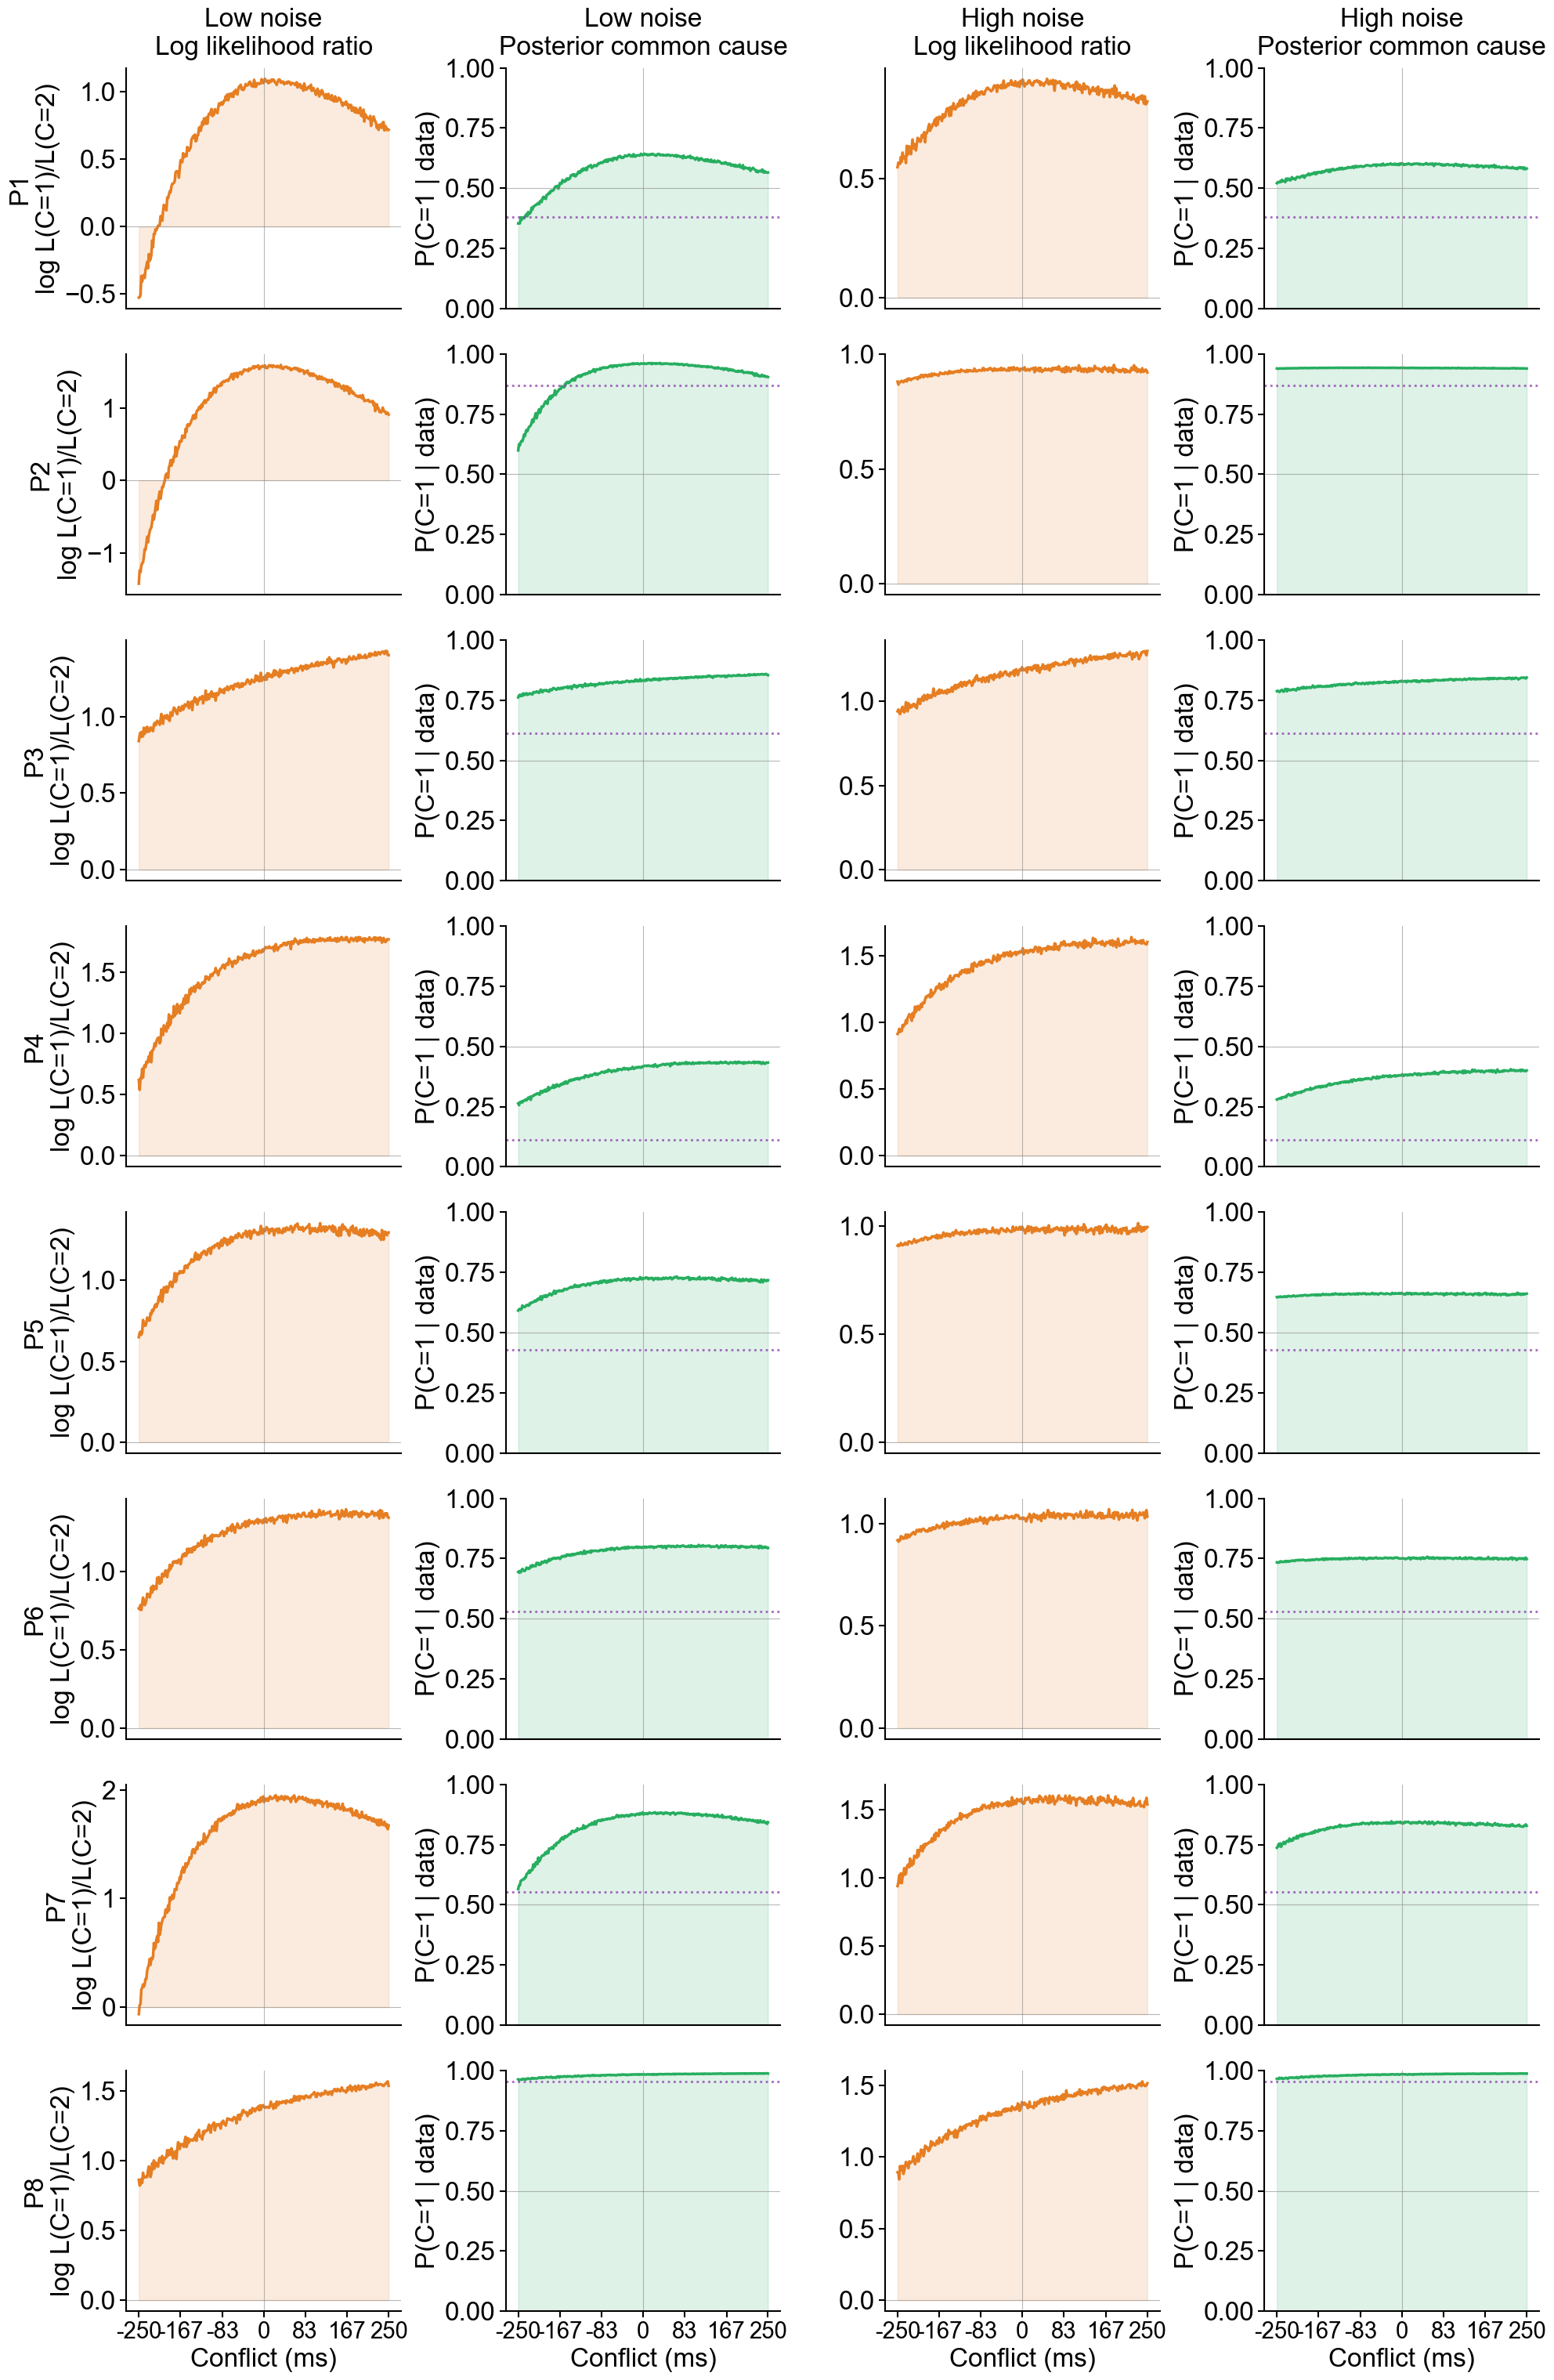

In [32]:

FONTSIZE = 24

def plot_ratio_and_posterior(sigma_a=0.3, sigma_v=0.3, p_c=0.5, t_min=0.1, t_max=3,
                             measurement="log-space", nSimul=2000, axes=None,
                             show_titles=True, show_xlabel=True):
    """
    Plot log likelihood ratio and posterior P(C=1) across conflict levels.
    Expects axes with 2 subplots [ratio_ax, posterior_ax].
    """
    conflicts = np.linspace(-0.25, +0.25, 300)
    post_c_means = []
    log_ratio_means = []

    S_a_s = 0.5

    for conflict in conflicts:
        S_v_s = S_a_s + conflict

        if measurement == "log-space" and S_v_s <= 0:
            log_ratio_means.append(np.nan)
            post_c_means.append(np.nan)
            continue

        if measurement == "log-space":
            m_a_s = np.random.normal(np.log(S_a_s), sigma_a, nSimul)
            m_v_s = np.random.normal(np.log(S_v_s), sigma_v, nSimul)
            t_min_use, t_max_use = np.log(t_min), np.log(t_max)
        else:
            m_a_s = np.random.normal(S_a_s, sigma_a, nSimul)
            m_v_s = np.random.normal(S_v_s, sigma_v, nSimul)
            t_min_use, t_max_use = t_min, t_max

        L1 = L_C1(m_a_s, m_v_s, sigma_a, sigma_v, t_min_use, t_max_use)
        L2 = L_C2(m_a_s, m_v_s, sigma_a, sigma_v, t_min_use, t_max_use)

        post_c1 = posterior_C1(m_a_s, m_v_s, sigma_a, sigma_v, p_c, t_min_use, t_max_use)
        post_c_means.append(np.mean(post_c1))

        with np.errstate(divide='ignore', invalid='ignore'):
            log_ratio = np.log(L1) - np.log(L2)
            log_ratio_means.append(np.mean(log_ratio))

    conflicts_ms = np.array(conflicts) * 1000

    # --- Plot 1: Log likelihood ratio ---
    ax_r = axes[0]
    ax_r.plot(conflicts_ms, log_ratio_means, color='#e67e22', linewidth=2.5)
    ax_r.fill_between(conflicts_ms, 0, log_ratio_means, alpha=0.15, color='#e67e22')
    ax_r.axhline(0, color='#888888', linestyle='-', linewidth=0.8, alpha=0.6)
    ax_r.axvline(0, color='#888888', linestyle='-', linewidth=0.8, alpha=0.6)

    if show_titles:
        ax_r.set_title('Log likelihood ratio', fontsize=FONTSIZE, pad=10)
    ax_r.spines['top'].set_visible(False)
    ax_r.spines['right'].set_visible(False)
    ax_r.tick_params(axis='both', labelsize=FONTSIZE)

    # --- Plot 2: Posterior P(C=1) ---
    ax_p = axes[1]
    ax_p.plot(conflicts_ms, post_c_means, color='#27ae60', linewidth=2.5)
    ax_p.fill_between(conflicts_ms, 0, post_c_means, alpha=0.15, color='#27ae60')
    ax_p.axhline(0.5, color='#888888', linestyle='-', linewidth=0.8, alpha=0.6)
    ax_p.axhline(p_c, color='#8e44ad', linestyle=':', linewidth=2, alpha=0.8)
    ax_p.axvline(0, color='#888888', linestyle='-', linewidth=0.8, alpha=0.6)
    ax_p.set_ylabel('P(C=1 | data)', fontsize=FONTSIZE)
    if show_titles:
        ax_p.set_title('Posterior common cause', fontsize=FONTSIZE, pad=10)
    ax_p.set_ylim([0, 1])
    ax_p.spines['top'].set_visible(False)
    ax_p.spines['right'].set_visible(False)
    ax_p.tick_params(axis='both', labelsize=FONTSIZE)

    # x-axis
    if show_xlabel:
        x_ticks = [-250, -167, -83, 0, 83, 167, 250]
        for ax in axes:
            ax.set_xticks(x_ticks)
            ax.set_xticklabels([str(t) for t in x_ticks], fontsize=FONTSIZE-3)
        axes[0].set_xlabel('Conflict (ms)', fontsize=FONTSIZE)
        axes[1].set_xlabel('Conflict (ms)', fontsize=FONTSIZE)
    else:
        for ax in axes:
            ax.set_xticks([])
            ax.set_xticklabels([])


def plotPosteriorsPerSubj(participantIds, modelTypes, parameterToPLot="mu"):
    lenSubjs = len(participantIds)
    nNoiseLevels = 2
    nPlotsPerNoise = 2  # ratio + posterior only

    n_cols = nNoiseLevels * nPlotsPerNoise  # 4 columns total
    fig, axes = plt.subplots(
        lenSubjs, n_cols,
        figsize=(5 * n_cols, 4 * lenSubjs),
        squeeze=False
    )
    plt.subplots_adjust(hspace=0.35, wspace=0.35, top=0.94)

    noise_labels = {0.1: "Low noise", 1.2: "High noise"}

    for pNum, participantID in enumerate(participantIds):
        for j, audioNoiseLevel in enumerate([0.1, 1.2]):
            # Load data and fit
            data, dataName = load_participant_data(participantID)
            mc_fitter = monteCarloClass.OmerMonteCarlo(data)
            mc_fitter.modelName = "lognorm"
            mc_fitter.freeP_c = False
            mc_fitter.sharedLambda = False
            mc_fitter.dataName = dataName
            res = get_fit_result(participantID, model_name=mc_fitter.modelName)
            mc_fitter.modelFit = res['fittedParams']

            sigma_v = mc_fitter.modelFit[2]
            p_c = mc_fitter.modelFit[3]
            sigma_a = mc_fitter.modelFit[1] if audioNoiseLevel == 0.1 else mc_fitter.modelFit[4]

            start_col = j * nPlotsPerNoise
            subplot_axes = [axes[pNum, start_col + k] for k in range(nPlotsPerNoise)]

            is_first_row = (pNum == 0)
            is_last_row = (pNum == lenSubjs - 1)

            plot_ratio_and_posterior(
                sigma_a=sigma_a, sigma_v=sigma_v, p_c=p_c,
                t_min=mc_fitter.data_t_min, t_max=mc_fitter.data_t_max,
                measurement="log-space",
                axes=subplot_axes,
                show_titles=is_first_row,
                show_xlabel=is_last_row
            )

            # Add participant + noise label on the left-most column of each noise block
            noise_label = noise_labels[audioNoiseLevel]
            if is_first_row:
                current_title = subplot_axes[0].get_title()
                subplot_axes[0].set_title(
                    f"{noise_label}\n{current_title}",
                    fontsize=FONTSIZE, pad=12
                )
                current_title_p = subplot_axes[1].get_title()
                subplot_axes[1].set_title(
                    f"{noise_label}\n{current_title_p}",
                    fontsize=FONTSIZE, pad=12
                )

        # Add participant label on y-axis of leftmost column
        axes[pNum, 0].set_ylabel(f'P{pNum+1}\nlog L(C=1)/L(C=2)', fontsize=FONTSIZE)
        if pNum == lenSubjs//2 - 1:
            axes[pNum, 0].set_ylabel(f'P{pNum+1}\nlog L(C=1)/L(C=2)', fontsize=FONTSIZE)

    plt.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig("posterior_ratio_per_subject.png", dpi=600, format='png', bbox_inches='tight')
    plt.show()

# Run
plotPosteriorsPerSubj(participantIds[1:9], modelTypes, parameterToPLot="mu")


## V2: Overlay both log-likelihoods + posterior (2-panel layout)

Revised figure per PI feedback: drop the log-likelihood ratio panel. Instead, overlay both log-likelihoods on the **same axes** so the reader can directly compare $\log P(\mathbf{m}\mid C{=}1)$ vs $\log P(\mathbf{m}\mid C{=}2)$ at every conflict level. Second panel shows the resulting posterior $P(C{=}1\mid\mathbf{m})$.

**Figure caption (manuscript, V2):** Marginal likelihoods and posterior probability of a common cause for an example participant, plotted as a function of audiovisual duration conflict. The top row shows the low-auditory-noise condition; the bottom row shows the high-auditory-noise condition. Left: the log marginal likelihoods under a common cause ($\log P(m_a, m_v \mid C{=}1)$, blue) and under separate causes ($\log P(m_a, m_v \mid C{=}2)$, red), plotted on the same axes so their relative magnitudes can be compared directly. Right: the posterior probability of a common cause, $P(C{=}1 \mid m_a, m_v)$, with the dotted purple line marking the fitted prior $p_c$. All quantities were computed via Monte Carlo simulation using participant-specific sensory-noise estimates ($\sigma_a$, $\sigma_v$) and the common-cause prior ($p_c$) obtained from the log-normal causal-inference model fit.

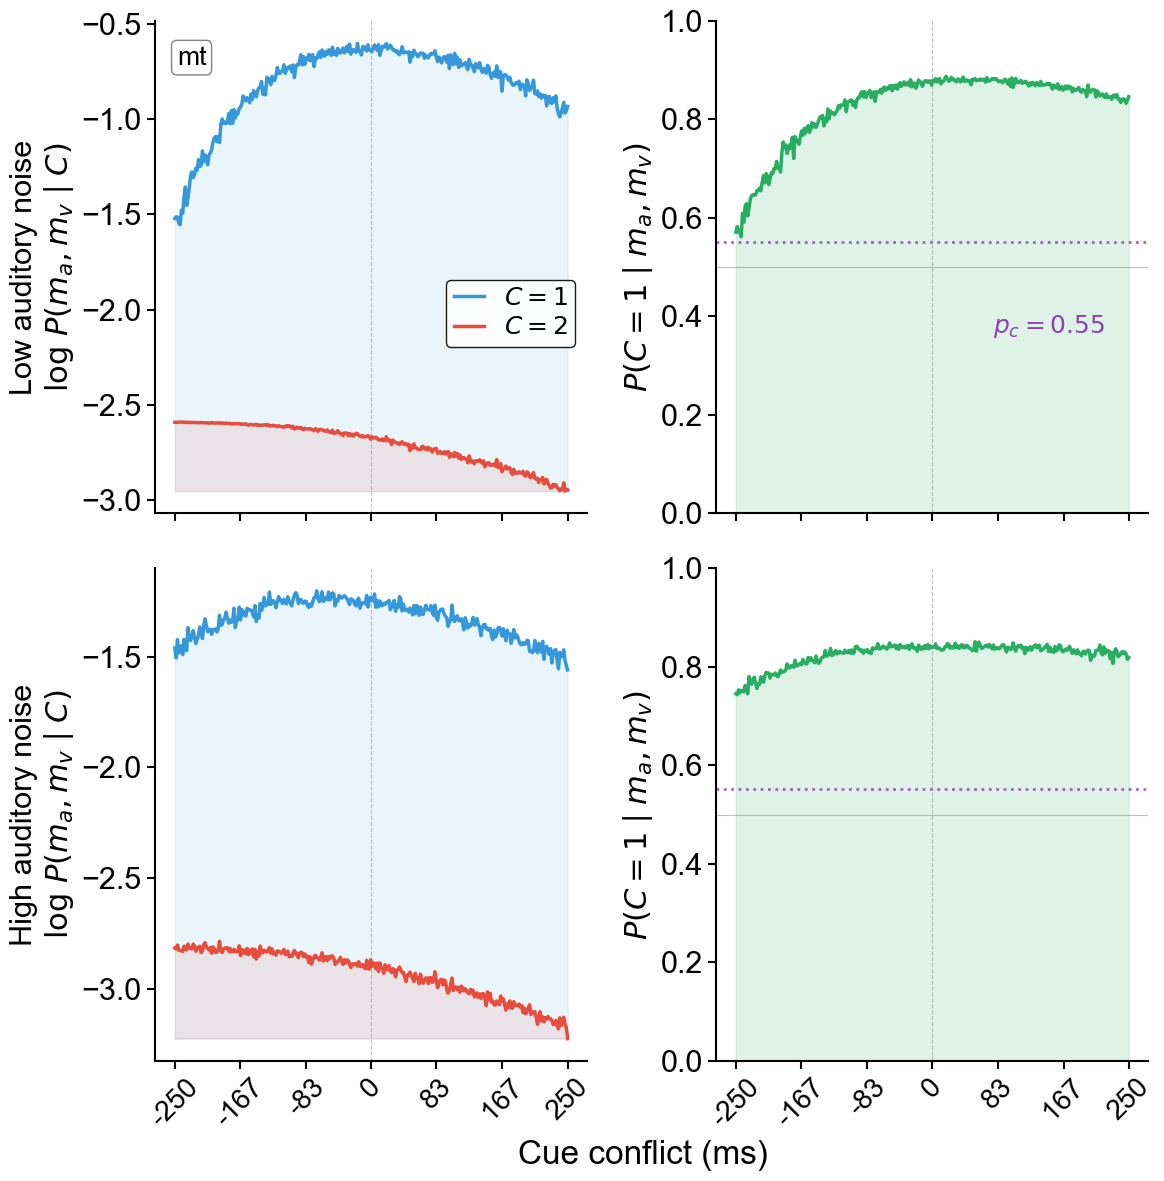

Saved manuscript_posterior_mt_v2.png/.pdf


In [33]:
# V2: 2-panel overlay — single participant (manuscript figure)
# Layout: 2 rows (low/high noise) × 2 columns (overlaid likelihoods, posterior)

import matplotlib.pyplot as plt
import numpy as np

FONTSIZE_V2 = 22

def plot_overlay_and_posterior(sigma_a, sigma_v, p_c, t_min, t_max,
                               measurement="log-space", nSimul=5000, axes=None,
                               show_titles=True, show_xlabel=True,
                               show_legend=True):
    """
    Panel 0 (A): Both log P(m|C=1) and log P(m|C=2) overlaid on the same axes.
    Panel 1 (B): Posterior P(C=1 | m_a, m_v).
    Expects axes with 2 subplots.
    show_legend: only True for the first row to avoid repetition.
    """
    conflicts = np.linspace(-0.25, +0.25, 300)
    L1_means, L2_means, post_c_means = [], [], []

    S_a_s = 0.5
    for conflict in conflicts:
        S_v_s = S_a_s + conflict
        if measurement == "log-space" and S_v_s <= 0:
            L1_means.append(np.nan); L2_means.append(np.nan)
            post_c_means.append(np.nan)
            continue

        if measurement == "log-space":
            m_a = np.random.normal(np.log(S_a_s), sigma_a, nSimul)
            m_v = np.random.normal(np.log(S_v_s), sigma_v, nSimul)
            t_lo, t_hi = np.log(t_min), np.log(t_max)
        else:
            m_a = np.random.normal(S_a_s, sigma_a, nSimul)
            m_v = np.random.normal(S_v_s, sigma_v, nSimul)
            t_lo, t_hi = t_min, t_max

        l1 = L_C1(m_a, m_v, sigma_a, sigma_v, t_lo, t_hi)
        l2 = L_C2(m_a, m_v, sigma_a, sigma_v, t_lo, t_hi)
        L1_means.append(np.mean(l1))
        L2_means.append(np.mean(l2))

        pc1 = posterior_C1(m_a, m_v, sigma_a, sigma_v, p_c, t_lo, t_hi)
        post_c_means.append(np.mean(pc1))

    x = np.array(conflicts) * 1000
    log_L1 = np.log(L1_means)
    log_L2 = np.log(L2_means)

    c1_col, c2_col, post_col, prior_col = '#3498db', '#e74c3c', '#27ae60', '#8e44ad'

    # --- Panel A: overlaid log-likelihoods ---
    ax = axes[0]
    ax.plot(x, log_L1, color=c1_col, linewidth=2.5, label=r'$C{=}1$')
    ax.fill_between(x, np.nanmin(np.concatenate([log_L1, log_L2])), log_L1,
                    alpha=0.10, color=c1_col)
    ax.plot(x, log_L2, color=c2_col, linewidth=2.5, label=r'$C{=}2$')
    ax.fill_between(x, np.nanmin(np.concatenate([log_L1, log_L2])), log_L2,
                    alpha=0.10, color=c2_col)
    ax.axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_ylabel(r'$\log\,P(m_a, m_v \mid C)$', fontsize=FONTSIZE_V2)
    if show_legend:
        ax.legend(fontsize=FONTSIZE_V2 - 4, loc='upper right', framealpha=0.9,
                  handlelength=1.2, borderpad=0.3, labelspacing=0.25, bbox_to_anchor=(1, 0.5))
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE_V2)

    # --- Panel B: posterior P(C=1) ---
    ax = axes[1]
    ax.plot(x, post_c_means, color=post_col, linewidth=2.5)
    ax.fill_between(x, 0, post_c_means, alpha=0.15, color=post_col)
    ax.axhline(0.5, color='gray', ls='-', lw=0.8, alpha=0.5)
    ax.axhline(p_c, color=prior_col, ls=':', lw=2, alpha=0.8)
    ax.axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_ylabel(r'$P(C{=}1 \mid m_a, m_v)$', fontsize=FONTSIZE_V2)
    ax.set_ylim([0, 1])
    if show_legend:
        ax.text(0.9, p_c-0.2 , f'$p_c = {p_c:.2f}$', transform=ax.get_yaxis_transform(),
                ha='right', va='bottom', fontsize=FONTSIZE_V2 - 4, color=prior_col)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE_V2)

    # x-axis ticks
    x_ticks = [-250, -167, -83, 0, 83, 167, 250]
    if show_xlabel:
        for a in axes:
            a.set_xticks(x_ticks)
            a.set_xticklabels([str(t) for t in x_ticks], fontsize=FONTSIZE_V2 - 2, rotation=45)
    else:
        for a in axes:
            a.set_xticks(x_ticks)
            a.set_xticklabels([])


# ── Build the 2-row × 2-col figure for the example participant (mt → P10) ──
participant_idx = participantIds.index('mt')  # example participant mt (anonymized P10)
participantID = participantIds[participant_idx]

fig, axes = plt.subplots(2, 2, figsize=(12, 12), squeeze=False)
plt.subplots_adjust(hspace=0.35, wspace=0.35)

noise_levels = [0.1, 1.2]
noise_labels = {0.1: 'Low auditory noise', 1.2: 'High auditory noise'}

for row, audioNoiseLevel in enumerate(noise_levels):
    data, dataName = load_participant_data(participantID)
    #data, dataName = loadData.loadData("all" + "_all.csv", verbose=False)
    mc_fitter = monteCarloClass.OmerMonteCarlo(data)
    mc_fitter.modelName = "lognorm"
    mc_fitter.freeP_c = False
    mc_fitter.sharedLambda = False
    mc_fitter.dataName = dataName
    res = get_fit_result(participantID, model_name=mc_fitter.modelName)
    mc_fitter.modelFit = res['fittedParams']

    sigma_v = mc_fitter.modelFit[2]
    p_c     = mc_fitter.modelFit[3]
    sigma_a = mc_fitter.modelFit[1] if audioNoiseLevel == 0.1 else mc_fitter.modelFit[4]

    row_axes = [axes[row, c] for c in range(2)]

    plot_overlay_and_posterior(
        sigma_a=sigma_a, sigma_v=sigma_v, p_c=p_c,
        t_min=mc_fitter.data_t_min, t_max=mc_fitter.data_t_max,
        measurement="log-space", nSimul=500,

        axes=row_axes,
        show_titles=(row == 0),
        show_xlabel=(row == 1),
        show_legend=(row == 0),
    )

    current_ylabel = row_axes[0].get_ylabel()
    row_axes[0].set_ylabel(
        f'{noise_labels[audioNoiseLevel]}\n{current_ylabel}', fontsize=FONTSIZE_V2)

# Add participant inset label in top-left panel (lowercase, e.g. 'p11')
participant_label_lower = participant_label(participantID).lower()
axes[0, 0].text(
    0.05, 0.95, participant_label_lower,
    transform=axes[0, 0].transAxes,
    ha='left', va='top', fontsize=FONTSIZE_V2 - 3,
    bbox=dict(facecolor='white', edgecolor='0.45', linewidth=1.0,
              boxstyle='round,pad=0.20', alpha=0.9),
)

#fig.suptitle(f'Participant {participantID.upper()} — Causal-inference likelihood decomposition (V2)',
             #fontsize=FONTSIZE_V2 + 4, y=1.01)
plt.tight_layout(rect=(0, 0, 1, 0.98))
fig.supxlabel('Cue conflict (ms)', fontsize=FONTSIZE_V2 + 2, x=0.55, y=-0.01)

participant_label_lower = participant_label(participantID).lower()
fig.savefig(f"manuscript_posterior_{participant_label_lower}_v2.png", dpi=600, bbox_inches='tight')
fig.savefig(f"manuscript_posterior_{participant_label_lower}_v2.pdf", dpi=900, bbox_inches='tight')
plt.show()
print(f"Saved manuscript_posterior_{participant_label_lower}_v2.png/.pdf")

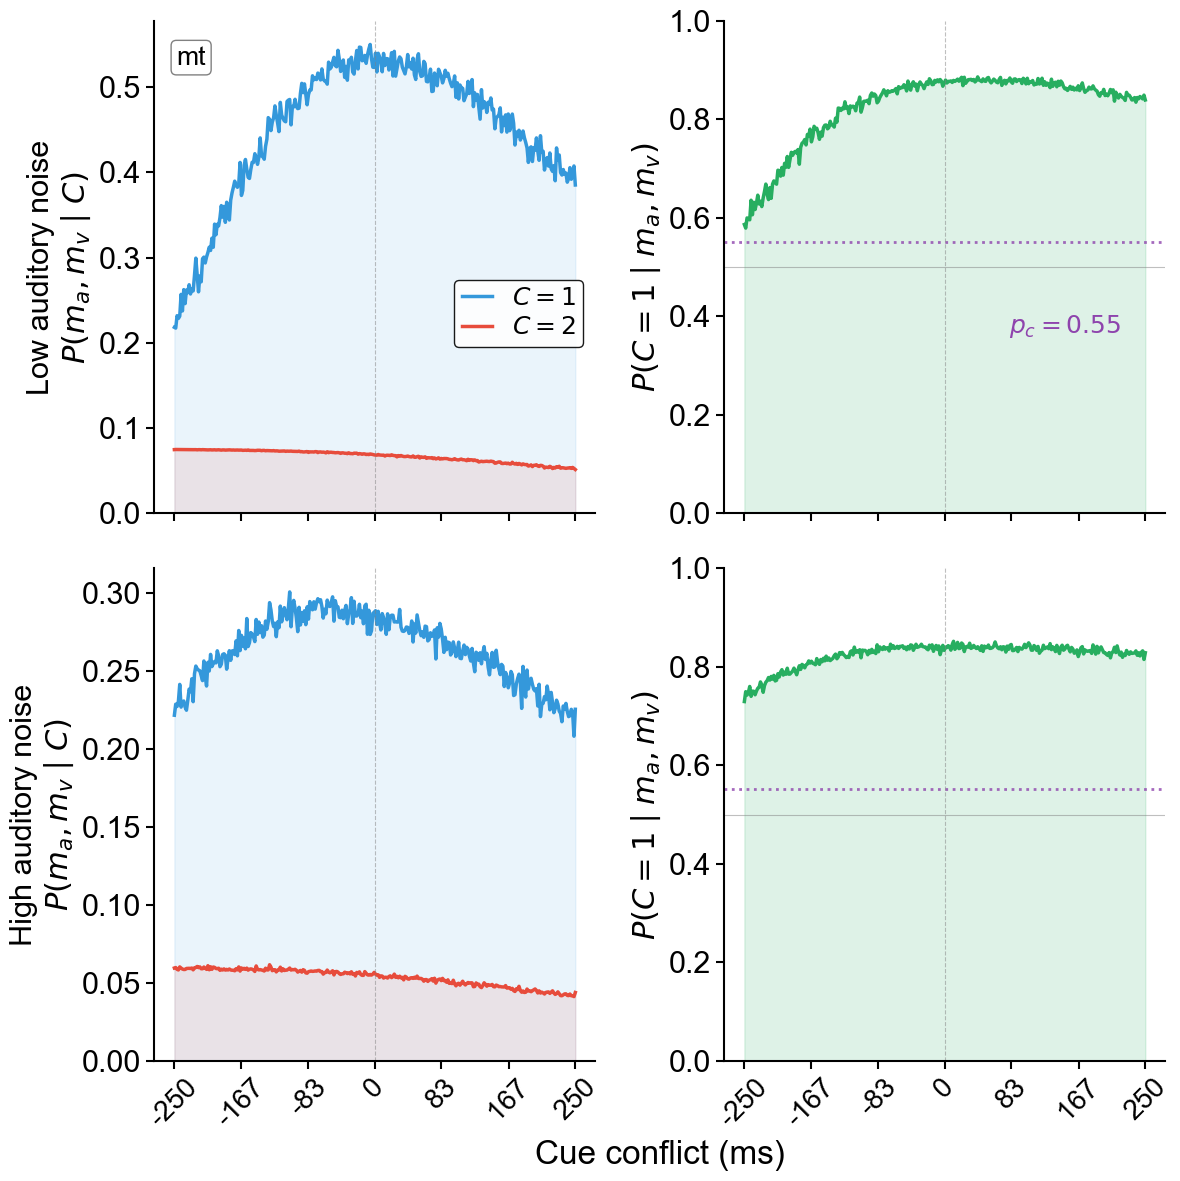

Saved manuscript_posterior_mt_v3.png/.pdf


In [34]:
# V3: 2-panel overlay with RAW (linear) likelihoods — single participant (manuscript figure)
# Identical to the V2 overlay, but Panel A shows the raw likelihoods P(m_a,m_v|C)
# on a linear y-axis instead of log P(m_a,m_v|C). Panel B (posterior) is unchanged.
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE_V3 = 22

def plot_overlay_and_posterior_raw(sigma_a, sigma_v, p_c, t_min, t_max,
                                   measurement="log-space", nSimul=5000, axes=None,
                                   show_titles=True, show_xlabel=True,
                                   show_legend=True):
    """
    Panel 0 (A): Both raw likelihoods P(m|C=1) and P(m|C=2) overlaid on a LINEAR axis.
    Panel 1 (B): Posterior P(C=1 | m_a, m_v).
    Expects axes with 2 subplots.
    """
    conflicts = np.linspace(-0.25, +0.25, 300)
    L1_means, L2_means, post_c_means = [], [], []

    S_a_s = 0.5
    for conflict in conflicts:
        S_v_s = S_a_s + conflict
        if measurement == "log-space" and S_v_s <= 0:
            L1_means.append(np.nan); L2_means.append(np.nan)
            post_c_means.append(np.nan)
            continue

        if measurement == "log-space":
            m_a = np.random.normal(np.log(S_a_s), sigma_a, nSimul)
            m_v = np.random.normal(np.log(S_v_s), sigma_v, nSimul)
            t_lo, t_hi = np.log(t_min), np.log(t_max)
        else:
            m_a = np.random.normal(S_a_s, sigma_a, nSimul)
            m_v = np.random.normal(S_v_s, sigma_v, nSimul)
            t_lo, t_hi = t_min, t_max

        l1 = L_C1(m_a, m_v, sigma_a, sigma_v, t_lo, t_hi)
        l2 = L_C2(m_a, m_v, sigma_a, sigma_v, t_lo, t_hi)
        L1_means.append(np.mean(l1))
        L2_means.append(np.mean(l2))

        pc1 = posterior_C1(m_a, m_v, sigma_a, sigma_v, p_c, t_lo, t_hi)
        post_c_means.append(np.mean(pc1))

    x = np.array(conflicts) * 1000
    L1 = np.array(L1_means)   # raw likelihood (no log)
    L2 = np.array(L2_means)

    c1_col, c2_col, post_col, prior_col = '#3498db', '#e74c3c', '#27ae60', '#8e44ad'

    # --- Panel A: overlaid RAW likelihoods (linear y-axis) ---
    ax = axes[0]
    ax.plot(x, L1, color=c1_col, linewidth=2.5, label=r'$C{=}1$')
    ax.fill_between(x, 0, L1, alpha=0.10, color=c1_col)
    ax.plot(x, L2, color=c2_col, linewidth=2.5, label=r'$C{=}2$')
    ax.fill_between(x, 0, L2, alpha=0.10, color=c2_col)
    ax.axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_ylabel(r'$P(m_a, m_v \mid C)$', fontsize=FONTSIZE_V3)
    ax.set_ylim(bottom=0)
    if show_legend:
        ax.legend(fontsize=FONTSIZE_V3 - 4, loc='upper right', framealpha=0.9,
                  handlelength=1.2, borderpad=0.3, labelspacing=0.25, bbox_to_anchor=(1, 0.5))
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE_V3)

    # --- Panel B: posterior P(C=1) ---
    ax = axes[1]
    ax.plot(x, post_c_means, color=post_col, linewidth=2.5)
    ax.fill_between(x, 0, post_c_means, alpha=0.15, color=post_col)
    ax.axhline(0.5, color='gray', ls='-', lw=0.8, alpha=0.5)
    ax.axhline(p_c, color=prior_col, ls=':', lw=2, alpha=0.8)
    ax.axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_ylabel(r'$P(C{=}1 \mid m_a, m_v)$', fontsize=FONTSIZE_V3)
    ax.set_ylim([0, 1])
    if show_legend:
        ax.text(0.9, p_c-0.2 , f'$p_c = {p_c:.2f}$', transform=ax.get_yaxis_transform(),
                ha='right', va='bottom', fontsize=FONTSIZE_V3 - 4, color=prior_col)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE_V3)

    # x-axis ticks
    x_ticks = [-250, -167, -83, 0, 83, 167, 250]
    if show_xlabel:
        for a in axes:
            a.set_xticks(x_ticks)
            a.set_xticklabels([str(t) for t in x_ticks], fontsize=FONTSIZE_V3 - 2, rotation=45)
    else:
        for a in axes:
            a.set_xticks(x_ticks)
            a.set_xticklabels([])


# ── Build the 2-row × 2-col figure for the example participant (ml → p2) ──
participant_idx = participantIds.index('mt')  # example participant ml (anonymized p2)
participantID = participantIds[participant_idx]
participant_label_lower = participant_label(participantID).lower()

fig, axes = plt.subplots(2, 2, figsize=(12, 12), squeeze=False)
plt.subplots_adjust(hspace=0.35, wspace=0.35)

noise_levels = [0.1, 1.2]
noise_labels = {0.1: 'Low auditory noise', 1.2: 'High auditory noise'}

for row, audioNoiseLevel in enumerate(noise_levels):
    data, dataName = load_participant_data(participantID)
    mc_fitter = monteCarloClass.OmerMonteCarlo(data)
    mc_fitter.modelName = "lognorm"
    mc_fitter.freeP_c = False
    mc_fitter.sharedLambda = False
    mc_fitter.dataName = dataName
    res = get_fit_result(participantID, model_name=mc_fitter.modelName)
    mc_fitter.modelFit = res['fittedParams']

    sigma_v = mc_fitter.modelFit[2]
    p_c     = mc_fitter.modelFit[3]
    sigma_a = mc_fitter.modelFit[1] if audioNoiseLevel == 0.1 else mc_fitter.modelFit[4]

    row_axes = [axes[row, c] for c in range(2)]

    plot_overlay_and_posterior_raw(
        sigma_a=sigma_a, sigma_v=sigma_v, p_c=p_c,
        t_min=mc_fitter.data_t_min, t_max=mc_fitter.data_t_max,
        measurement="log-space", nSimul=500,
        axes=row_axes,
        show_titles=(row == 0),
        show_xlabel=(row == 1),
        show_legend=(row == 0),
    )

    current_ylabel = row_axes[0].get_ylabel()
    row_axes[0].set_ylabel(
        f'{noise_labels[audioNoiseLevel]}\n{current_ylabel}', fontsize=FONTSIZE_V3)

axes[0, 0].text(
    0.05, 0.95, participant_label_lower,
    transform=axes[0, 0].transAxes,
    ha='left', va='top', fontsize=FONTSIZE_V3 - 3,
    bbox=dict(facecolor='white', edgecolor='0.45', linewidth=1.0,
              boxstyle='round,pad=0.20', alpha=0.9),
)

plt.tight_layout(rect=(0, 0, 1, 0.98))
fig.supxlabel('Cue conflict (ms)', fontsize=FONTSIZE_V3 + 2, x=0.55, y=-0.01)

fig.savefig(f"manuscript_posterior_{participant_label_lower}_v3.png", dpi=600, bbox_inches='tight')
fig.savefig(f"manuscript_posterior_{participant_label_lower}_v3.pdf", dpi=900, bbox_inches='tight')
plt.show()
print(f"Saved manuscript_posterior_{participant_label_lower}_v3.png/.pdf")


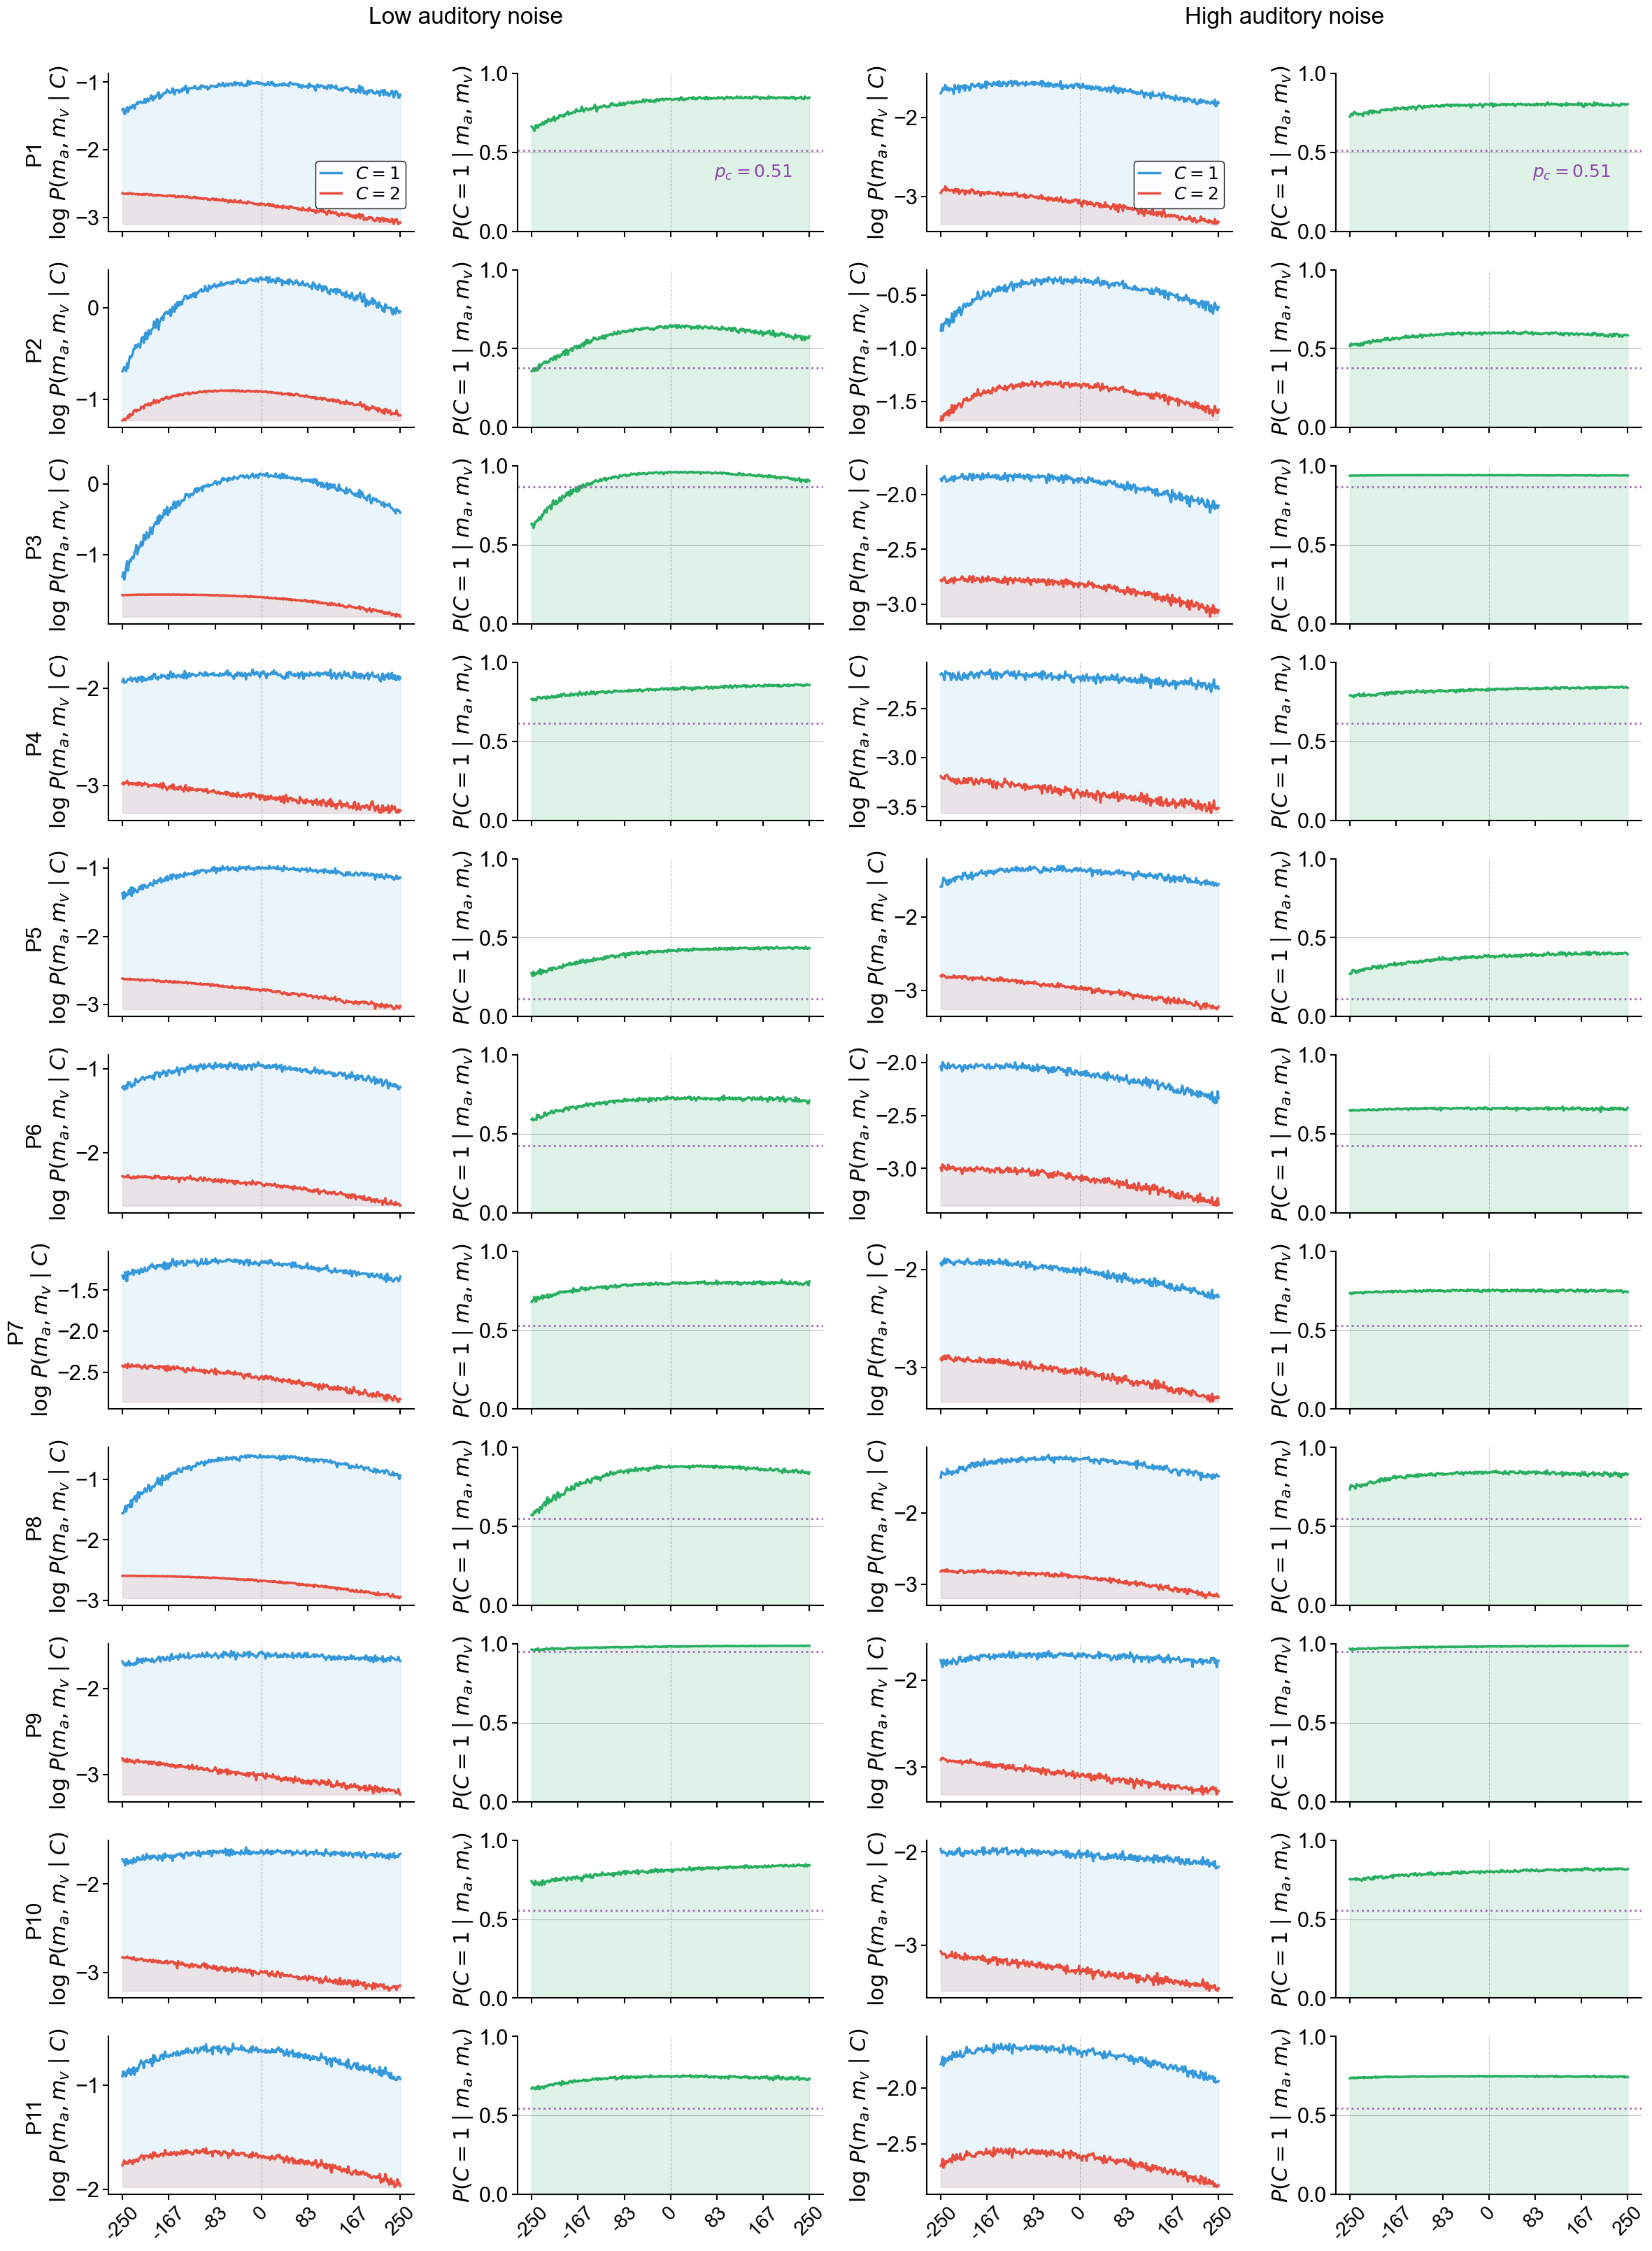

In [35]:
# V2: 2-panel overlay — all participants

def plotPosteriorsPerSubj_v2(participantIds, modelTypes, parameterToPLot="mu"):
    lenSubjs = len(participantIds)
    nNoiseLevels = 2
    nPlotsPerNoise = 2  # overlay + posterior

    n_cols = nNoiseLevels * nPlotsPerNoise  # 4 columns total
    fig, axes = plt.subplots(
        lenSubjs, n_cols,
        figsize=(6 * n_cols, 3 * lenSubjs),
        squeeze=False
    )
    plt.subplots_adjust(hspace=0.35, wspace=0.35, top=0.94)

    noise_labels = {0.1: "Low noise", 1.2: "High noise"}

    for pNum, participantID in enumerate(participantIds):
        for j, audioNoiseLevel in enumerate([0.1, 1.2]):
            data, dataName = load_participant_data(participantID)
            mc_fitter = monteCarloClass.OmerMonteCarlo(data)
            mc_fitter.modelName = "lognorm"
            mc_fitter.freeP_c = False
            mc_fitter.sharedLambda = False
            mc_fitter.dataName = dataName
            res = get_fit_result(participantID, model_name=mc_fitter.modelName)
            mc_fitter.modelFit = res['fittedParams']

            sigma_v = mc_fitter.modelFit[2]
            p_c = mc_fitter.modelFit[3]
            sigma_a = mc_fitter.modelFit[1] if audioNoiseLevel == 0.1 else mc_fitter.modelFit[4]

            start_col = j * nPlotsPerNoise
            subplot_axes = [axes[pNum, start_col + k] for k in range(nPlotsPerNoise)]

            is_first_row = (pNum == 0)
            is_last_row = (pNum == lenSubjs - 1)

            plot_overlay_and_posterior(
                sigma_a=sigma_a, sigma_v=sigma_v, p_c=p_c,
                t_min=mc_fitter.data_t_min, t_max=mc_fitter.data_t_max,
                measurement="log-space", nSimul=500,
                axes=subplot_axes,
                show_titles=is_first_row,
                show_xlabel=is_last_row,
                show_legend=is_first_row,
            )

        current_ylabel = axes[pNum, 0].get_ylabel()
        axes[pNum, 0].set_ylabel(
            f'{SEQ_LABELS[participantID]}\n{current_ylabel}', fontsize=FONTSIZE_V2)

    # plt.suptitle(
    #     r"Log marginal likelihoods and $P(C{=}1 \mid m_a, m_v)$ per participant (V2)",
    #     fontsize=FONTSIZE_V2 + 2, y=0.995)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    left_center = (axes[0, 0].get_position().x0 + axes[0, 1].get_position().x1) / 2
    right_center = (axes[0, 2].get_position().x0 + axes[0, 3].get_position().x1) / 2
    fig.text(left_center, 0.97, 'Low auditory noise', ha='center', fontsize=FONTSIZE_V2 + 2)
    fig.text(right_center, 0.97, 'High auditory noise', ha='center', fontsize=FONTSIZE_V2 + 2)
    fig.savefig("posterior_overlay_per_subject_v2.pdf", dpi=600, format='pdf', bbox_inches='tight')
    plt.show()

plotPosteriorsPerSubj_v2(participantIds[:], modelTypes, parameterToPLot="mu")



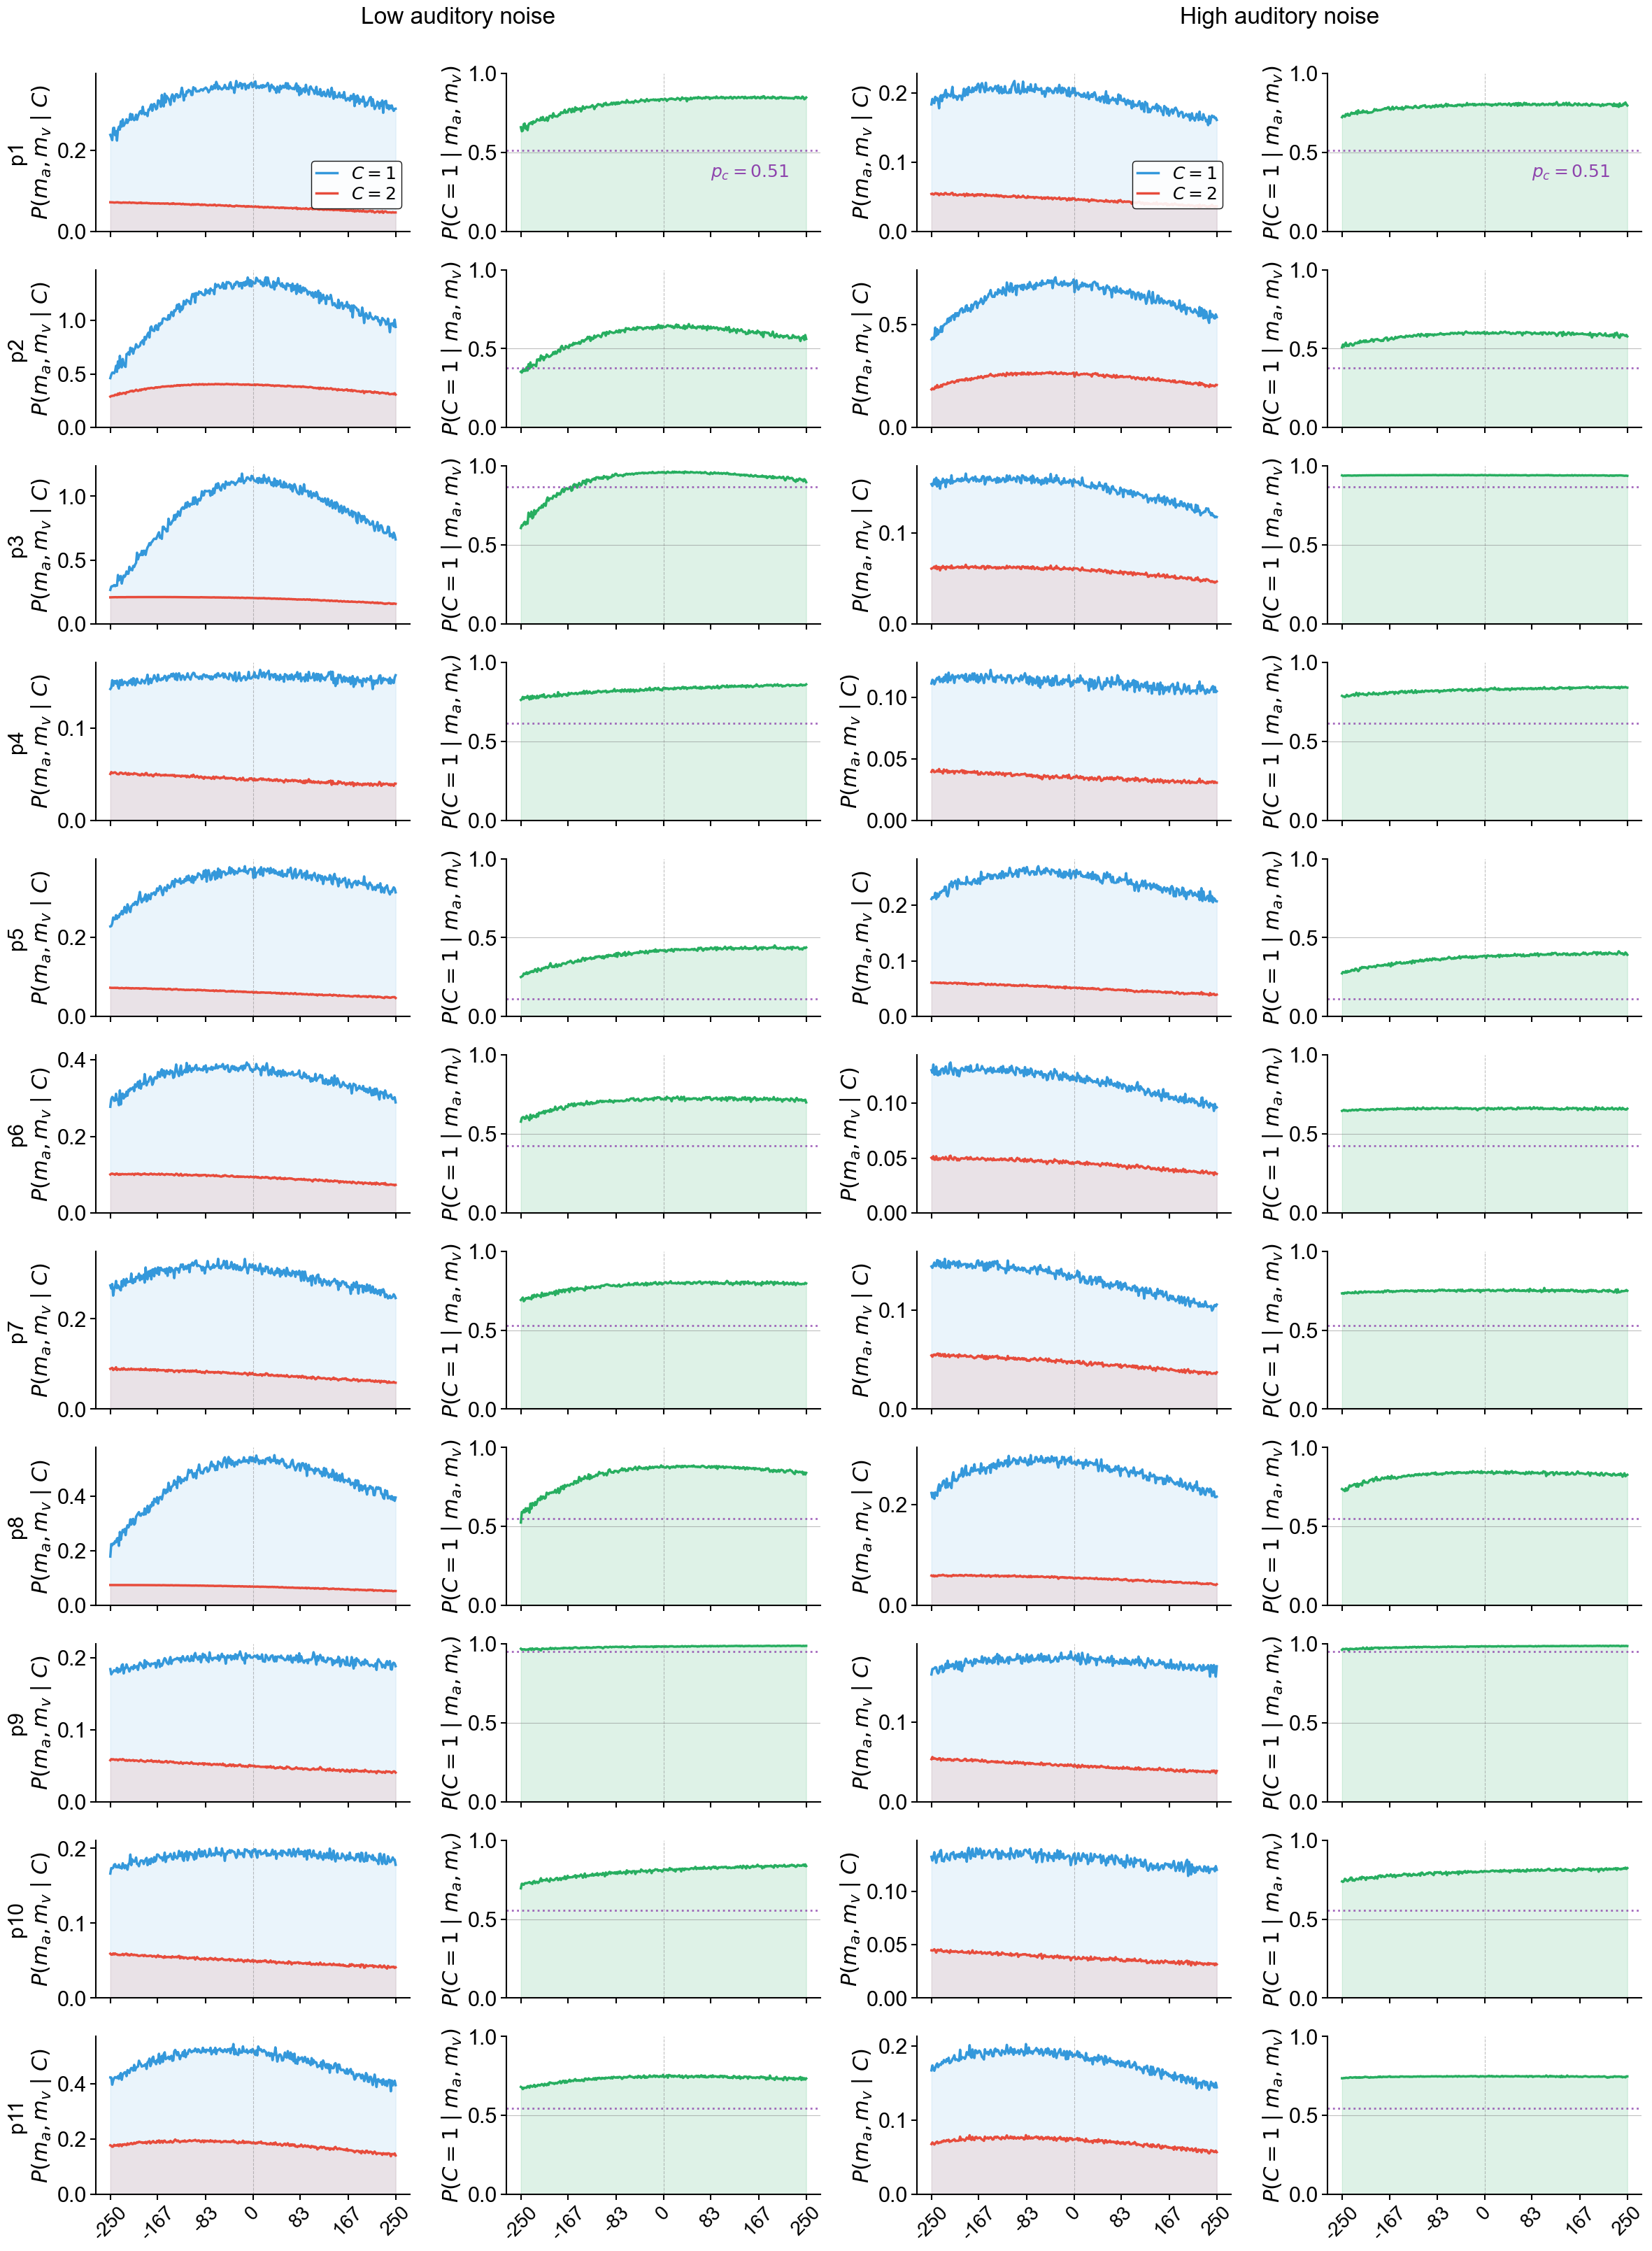

In [36]:
# V3: 2-panel overlay with RAW (linear) likelihoods — all participants
# Same as the V2 all-participant overlay, but Panel A uses raw P(m_a,m_v|C) on a
# linear y-axis (plot_overlay_and_posterior_raw) instead of log P.

def plotPosteriorsPerSubj_v3(participantIds, modelTypes, parameterToPLot="mu"):
    lenSubjs = len(participantIds)
    nNoiseLevels = 2
    nPlotsPerNoise = 2  # overlay + posterior

    n_cols = nNoiseLevels * nPlotsPerNoise  # 4 columns total
    fig, axes = plt.subplots(
        lenSubjs, n_cols,
        figsize=(6 * n_cols, 3 * lenSubjs),
        squeeze=False
    )
    plt.subplots_adjust(hspace=0.35, wspace=0.35, top=0.94)

    noise_labels = {0.1: "Low noise", 1.2: "High noise"}

    for pNum, participantID in enumerate(participantIds):
        for j, audioNoiseLevel in enumerate([0.1, 1.2]):
            data, dataName = load_participant_data(participantID)
            mc_fitter = monteCarloClass.OmerMonteCarlo(data)
            mc_fitter.modelName = "lognorm"
            mc_fitter.freeP_c = False
            mc_fitter.sharedLambda = False
            mc_fitter.dataName = dataName
            res = get_fit_result(participantID, model_name=mc_fitter.modelName)
            mc_fitter.modelFit = res['fittedParams']

            sigma_v = mc_fitter.modelFit[2]
            p_c = mc_fitter.modelFit[3]
            sigma_a = mc_fitter.modelFit[1] if audioNoiseLevel == 0.1 else mc_fitter.modelFit[4]

            start_col = j * nPlotsPerNoise
            subplot_axes = [axes[pNum, start_col + k] for k in range(nPlotsPerNoise)]

            is_first_row = (pNum == 0)
            is_last_row = (pNum == lenSubjs - 1)

            plot_overlay_and_posterior_raw(
                sigma_a=sigma_a, sigma_v=sigma_v, p_c=p_c,
                t_min=mc_fitter.data_t_min, t_max=mc_fitter.data_t_max,
                measurement="log-space", nSimul=500,
                axes=subplot_axes,
                show_titles=is_first_row,
                show_xlabel=is_last_row,
                show_legend=is_first_row,
            )

        current_ylabel = axes[pNum, 0].get_ylabel()
        axes[pNum, 0].set_ylabel(
            f'{SEQ_LABELS[participantID].lower()}\n{current_ylabel}', fontsize=FONTSIZE_V3)

    plt.tight_layout(rect=(0, 0, 1, 0.96))
    left_center = (axes[0, 0].get_position().x0 + axes[0, 1].get_position().x1) / 2
    right_center = (axes[0, 2].get_position().x0 + axes[0, 3].get_position().x1) / 2
    fig.text(left_center, 0.97, 'Low auditory noise', ha='center', fontsize=FONTSIZE_V3 + 2)
    fig.text(right_center, 0.97, 'High auditory noise', ha='center', fontsize=FONTSIZE_V3 + 2)
    fig.savefig("posterior_overlay_per_subject_v3.pdf", dpi=600, format='pdf', bbox_inches='tight')
    plt.show()

plotPosteriorsPerSubj_v3(participantIds[:], modelTypes, parameterToPLot="mu")


## Within-Participant Test: Does Posterior P(C=1) Vary Across Conflict Levels?

If causal inference is doing meaningful work, the posterior P(C=1) should drop substantially at high conflicts (observer detects separate causes). If it stays near-constant, the CI model collapses to forced fusion — the causal inference mechanism is not distinguishable from always fusing.

**Analysis:**
1. For each participant × noise level, compute E[P(C=1)] at the 7 experimental conflict levels via Monte Carlo
2. Compute per-participant **range** (max − min) and **coefficient of variation** of the posterior across conflicts
3. Run a **Friedman test** (non-parametric repeated measures) across participants to test whether posterior systematically varies with conflict
4. Visualise with stripplot + individual participant trajectories

In [37]:
import scipy.stats as stats

NSIML = 5000
rng = np.random.default_rng(0)

pids_to_analyse = [p for p in sorted(df_results['participantID'].unique()) if p != 'all']

posterior_rows = []

for pid in pids_to_analyse:
    data, dataName = load_participant_data(pid)
    mc = monteCarloClass.OmerMonteCarlo(data)
    mc.modelName = "lognorm"
    mc.freeP_c = False
    mc.sharedLambda = False
    mc.dataName = dataName

    res = get_fit_result(pid, model_name=mc.modelName)
    fitted = res['fittedParams']

    sigma_v = fitted[2]
    p_c     = fitted[3]
    log_t_min = np.log(mc.data_t_min)
    log_t_max = np.log(mc.data_t_max)

    sigma_a_map = {
        sorted(mc.uniqueSensory)[0]: fitted[1],
        sorted(mc.uniqueSensory)[1]: fitted[4],
    }

    for noise_level in sorted(mc.uniqueSensory):
        sigma_a = sigma_a_map[noise_level]
        for conflict in sorted(mc.uniqueConflict):
            S_v = 0.5 + conflict
            if S_v <= 0:
                continue
            m_a = rng.normal(np.log(0.5), sigma_a, NSIML)
            m_v = rng.normal(np.log(S_v), sigma_v, NSIML)
            post_samples = posterior_C1(m_a, m_v, sigma_a, sigma_v, p_c, log_t_min, log_t_max)
            mean_post = float(np.nanmean(post_samples))

            posterior_rows.append({
                'participantID': pid,
                'audioNoise': noise_level,
                'conflict_s': conflict,
                'conflict_ms': int(round(conflict * 1000)),
                'mean_posterior': mean_post,
                'sigma_a': sigma_a,
                'sigma_v': sigma_v,
                'p_c': p_c,
            })

df_post = pd.DataFrame(posterior_rows)
print(f"Computed posteriors: {len(df_post)} rows, {df_post['participantID'].nunique()} participants")
print(f"\nGrand mean posterior by conflict level:")
print(df_post.groupby(['audioNoise', 'conflict_ms'])['mean_posterior'].mean().round(3).to_string())

Computed posteriors: 154 rows, 11 participants

Grand mean posterior by conflict level:
audioNoise  conflict_ms
0.1         -250           0.623
            -170           0.717
            -80            0.767
             0             0.783
             80            0.788
             170           0.784
             250           0.775
1.2         -250           0.712
            -170           0.738
            -80            0.753
             0             0.758
             80            0.760
             170           0.761
             250           0.759


In [38]:
# ── Per-participant summary statistics ─────────────────────────────────────────
noise_labels = {0.1: 'Low noise', 1.2: 'High noise'}
summary_rows = []

for pid in pids_to_analyse:
    for noise in sorted(df_post['audioNoise'].unique()):
        mask = (df_post['participantID'] == pid) & (df_post['audioNoise'] == noise)
        vals = df_post.loc[mask, 'mean_posterior'].values
        if len(vals) == 0:
            continue
        summary_rows.append({
            'participant': participant_label(pid),
            'noise': noise_labels[noise],
            'min_post': vals.min(),
            'max_post': vals.max(),
            'range': vals.max() - vals.min(),
            'mean': vals.mean(),
            'CV': vals.std() / vals.mean() if vals.mean() > 0 else np.nan,
            'p_c_prior': df_post.loc[mask, 'p_c'].iloc[0],
        })

df_summary = pd.DataFrame(summary_rows)

print("=" * 80)
print("Per-participant posterior P(C=1) summary across 7 conflict levels")
print("=" * 80)
print(df_summary.to_string(index=False, float_format='{:.4f}'.format))

print(f"\n── Aggregate ──")
print(f"Mean range across participants & noise: {df_summary['range'].mean():.4f}")
print(f"Median range: {df_summary['range'].median():.4f}")
print(f"Max range:    {df_summary['range'].max():.4f}")
print(f"Mean CV:      {df_summary['CV'].mean():.4f}")

# ── Friedman test: does posterior vary with conflict? ──────────────────────────
print("\n" + "=" * 80)
print("Friedman test: P(C=1) ~ conflict level (within-participant)")
print("=" * 80)

for noise in sorted(df_post['audioNoise'].unique()):
    sub = df_post[df_post['audioNoise'] == noise]
    conflicts_sorted = sorted(sub['conflict_ms'].unique())

    groups = []
    for c in conflicts_sorted:
        vals = sub[sub['conflict_ms'] == c].sort_values('participantID')['mean_posterior'].values
        groups.append(vals)

    n_per_group = [len(g) for g in groups]
    if len(set(n_per_group)) > 1:
        min_n = min(n_per_group)
        groups = [g[:min_n] for g in groups]

    stat, p_val = stats.friedmanchisquare(*groups)
    n_subj = len(groups[0])
    k = len(groups)
    W = stat / (n_subj * (k - 1))  # Kendall's W effect size

    print(f"\n  {noise_labels[noise]}:")
    print(f"    χ²({k-1}) = {stat:.3f}, p = {p_val:.4f}, Kendall's W = {W:.4f}")
    print(f"    N = {n_subj} participants, k = {k} conflict levels")
    if p_val < 0.05:
        print(f"    → Significant variation (but check effect size W)")
    else:
        print(f"    → No significant variation in posterior across conflict levels")

# ── Paired comparison: extremes (-250 ms vs +250 ms) ─────────────────────────
print("\n" + "=" * 80)
print("Paired t-test / Wilcoxon: posterior at -250ms vs +250ms conflict")
print("=" * 80)

for noise in sorted(df_post['audioNoise'].unique()):
    sub = df_post[df_post['audioNoise'] == noise]
    pids_common = sorted(set(
        sub[sub['conflict_ms'] == -250]['participantID']
    ) & set(
        sub[sub['conflict_ms'] == 250]['participantID']
    ))

    lo = np.array([sub[(sub['participantID'] == p) & (sub['conflict_ms'] == -250)]['mean_posterior'].values[0]
                   for p in pids_common])
    hi = np.array([sub[(sub['participantID'] == p) & (sub['conflict_ms'] == 250)]['mean_posterior'].values[0]
                   for p in pids_common])

    diff = hi - lo
    t_stat, t_p = stats.ttest_rel(lo, hi)
    w_stat, w_p = stats.wilcoxon(lo, hi)
    cohens_d = np.mean(diff) / np.std(diff, ddof=1) if np.std(diff, ddof=1) > 0 else 0

    print(f"\n  {noise_labels[noise]} (N={len(pids_common)}):")
    print(f"    Mean post at -250ms: {lo.mean():.4f} ± {lo.std():.4f}")
    print(f"    Mean post at +250ms: {hi.mean():.4f} ± {hi.std():.4f}")
    print(f"    Mean difference:     {np.mean(diff):.4f}")
    print(f"    Paired t({len(pids_common)-1}) = {t_stat:.3f}, p = {t_p:.4f}")
    print(f"    Wilcoxon W = {w_stat:.1f}, p = {w_p:.4f}")
    print(f"    Cohen's d = {cohens_d:.3f}")

Per-participant posterior P(C=1) summary across 7 conflict levels
participant      noise  min_post  max_post  range   mean     CV  p_c_prior
         AS  Low noise    0.6598    0.8484 0.1886 0.8006 0.0809     0.5137
         AS High noise    0.7349    0.8039 0.0690 0.7873 0.0299     0.5137
         DT  Low noise    0.3521    0.6357 0.2836 0.5566 0.1684     0.3792
         DT High noise    0.5255    0.6001 0.0746 0.5799 0.0425     0.3792
         HH  Low noise    0.6050    0.9599 0.3549 0.8795 0.1337     0.8676
         HH High noise    0.9394    0.9425 0.0031 0.9413 0.0010     0.8676
         IP  Low noise    0.7623    0.8577 0.0954 0.8238 0.0381     0.6136
         IP High noise    0.7855    0.8417 0.0562 0.8217 0.0232     0.6136
        LN2  Low noise    0.2635    0.4376 0.1741 0.3873 0.1547     0.1121
        LN2 High noise    0.2804    0.3995 0.1191 0.3637 0.1116     0.1121
         MH  Low noise    0.5972    0.7264 0.1292 0.6953 0.0619     0.4267
         MH High noise    0.6475  

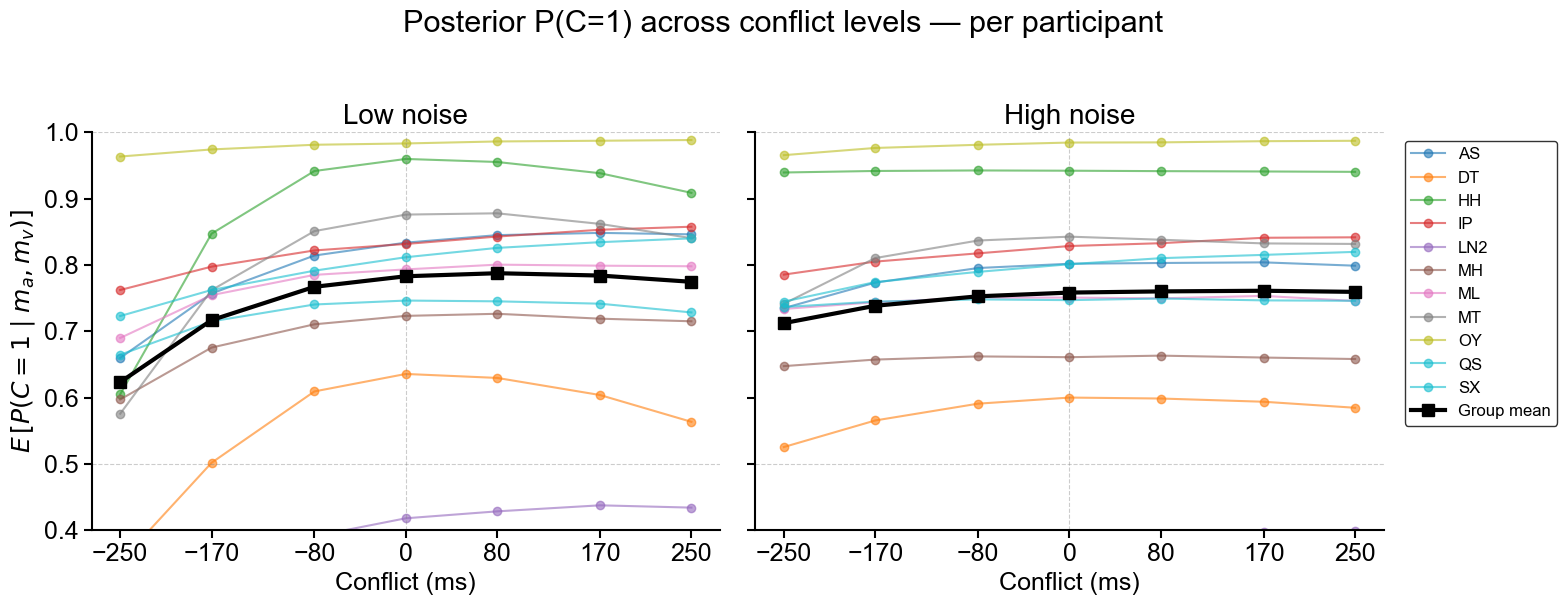

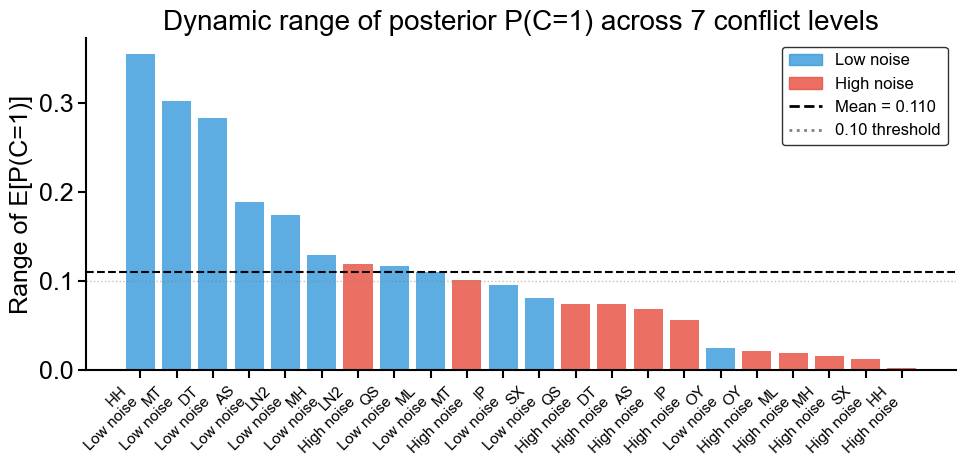


Figures saved: posterior_within_participant_conflict.pdf/.png
               posterior_range_per_participant.pdf/.png


In [39]:
# ── Figure: Posterior P(C=1) across conflict levels per participant ────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

cmap = plt.cm.tab10
participant_colors = {pid: cmap(i) for i, pid in enumerate(pids_to_analyse)}

for ax_idx, noise in enumerate(sorted(df_post['audioNoise'].unique())):
    ax = axes[ax_idx]
    sub = df_post[df_post['audioNoise'] == noise]

    for pid in pids_to_analyse:
        psub = sub[sub['participantID'] == pid].sort_values('conflict_ms')
        if psub.empty:
            continue
        ax.plot(psub['conflict_ms'], psub['mean_posterior'],
                marker='o', markersize=6, alpha=0.6, linewidth=1.5,
                color=participant_colors[pid], label=participant_label(pid))

    group_mean = sub.groupby('conflict_ms')['mean_posterior'].mean()
    ax.plot(group_mean.index, group_mean.values,
            color='black', linewidth=3, marker='s', markersize=8,
            zorder=10, label='Group mean')

    ax.axhline(1.0, color='gray', ls='--', lw=0.8, alpha=0.4)
    ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.4)
    ax.axvline(0, color='gray', ls='--', lw=0.8, alpha=0.4)

    ax.set_xlabel('Conflict (ms)')
    ax.set_title(noise_labels[noise])
    ax.set_ylim([0.4, 1.0])
    ax.set_xticks(sorted(sub['conflict_ms'].unique()))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel(r'$E\,[P(C{=}1 \mid m_a, m_v)]$')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, frameon=True)

fig.suptitle('Posterior P(C=1) across conflict levels — per participant',
             fontsize=FONT_SIZE_TITLE + 2, y=1.02)
plt.tight_layout()
plt.savefig('posterior_within_participant_conflict.pdf', bbox_inches='tight')
plt.savefig('posterior_within_participant_conflict.png', bbox_inches='tight', dpi=300)
plt.show()

# ── Figure: Range of posterior per participant (bar chart) ────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

df_summary_sorted = df_summary.sort_values('range', ascending=False)
x_labels = [f"{r['participant']}\n{r['noise']}" for _, r in df_summary_sorted.iterrows()]
colors = ['#3498db' if 'Low' in r['noise'] else '#e74c3c' for _, r in df_summary_sorted.iterrows()]

bars = ax.bar(range(len(df_summary_sorted)), df_summary_sorted['range'].values, color=colors, alpha=0.8)

ax.axhline(df_summary['range'].mean(), color='black', ls='--', lw=1.5,
           label=f"Mean range = {df_summary['range'].mean():.3f}")
ax.axhline(0.1, color='gray', ls=':', lw=1.0, alpha=0.5,
           label='Threshold = 0.10')

ax.set_xticks(range(len(df_summary_sorted)))
ax.set_xticklabels(x_labels, fontsize=11, rotation=45, ha='right')
ax.set_ylabel('Range of E[P(C=1)]')
ax.set_title('Dynamic range of posterior P(C=1) across 7 conflict levels')
ax.legend(fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

import matplotlib.patches as mpatches
low_patch = mpatches.Patch(color='#3498db', alpha=0.8, label='Low noise')
high_patch = mpatches.Patch(color='#e74c3c', alpha=0.8, label='High noise')
ax.legend(handles=[low_patch, high_patch,
                    plt.Line2D([0],[0], color='black', ls='--', label=f"Mean = {df_summary['range'].mean():.3f}"),
                    plt.Line2D([0],[0], color='gray', ls=':', label='0.10 threshold')],
          fontsize=12, loc='upper right')

plt.tight_layout()
plt.savefig('posterior_range_per_participant.pdf', bbox_inches='tight')
plt.savefig('posterior_range_per_participant.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"\nFigures saved: posterior_within_participant_conflict.pdf/.png")
print(f"               posterior_range_per_participant.pdf/.png")

## Comprehensive Analysis: Why Causal Inference ≈ Forced Fusion

### The chain of reasoning:
1. **Noise ≫ conflict in log-space** → The sensory noise (σ_a, σ_v) is large relative to the AV conflict range in log-space, so the likelihood ratio L(C=1)/L(C=2) barely changes across conflicts.
2. **Posterior P(C=1) is flat** → Because the likelihood ratio is near-constant, the posterior doesn't deviate much from the prior p_c regardless of conflict.
3. **CI collapses to fusion** → With P(C=1) ≈ constant ≈ high, the CI estimate ŝ = P(C=1)·ŝ_fused + (1−P(C=1))·m_a ≈ ŝ_fused. The effective visual weight in CI ≈ fusion visual weight.
4. **ΔAIC ≈ 0** → Because the models produce nearly identical behavioral predictions, they are statistically indistinguishable.

### Analyses:
- **(A)** ΔAIC(CI − Fusion) per participant — how close are the two models?
- **(B)** Posterior range vs. ΔAIC — does posterior flatness predict indistinguishability?
- **(C)** Effective visual weight: CI vs. Fusion — shows identical sensory weighting
- **(D)** Noise-to-conflict ratio — the root cause of the flat posterior
- **(E)** Prior p_c vs. mean posterior — shows the prior barely updates

In [40]:
# ══════════════════════════════════════════════════════════════════════════════
# Compute all metrics needed for the comprehensive analysis
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. ΔAIC / ΔBIC between CI (lognorm) and Forced Fusion per participant ────
aic_rows = []
for pid in pids_to_analyse:
    ci_row = df_results[(df_results['participantID'] == pid) &
                        (df_results['modelType'] == 'lognorm_sharedPrior')]
    fu_row = df_results[(df_results['participantID'] == pid) &
                        (df_results['modelType'] == 'fusionOnlyLogNorm_sharedPrior')]
    if ci_row.empty or fu_row.empty:
        print(f"  Skipping {pid}: missing lognorm or fusion fit")
        continue

    aic_rows.append({
        'participant': participant_label(pid),
        'delta_AIC': ci_row.iloc[0]['AIC'] - fu_row.iloc[0]['AIC'],
        'delta_BIC': ci_row.iloc[0]['BIC'] - fu_row.iloc[0]['BIC'],
        'delta_LL':  ci_row.iloc[0]['logLikelihood'] - fu_row.iloc[0]['logLikelihood'],
        'AIC_CI': ci_row.iloc[0]['AIC'],
        'AIC_fusion': fu_row.iloc[0]['AIC'],
    })
df_aic = pd.DataFrame(aic_rows)

# ── 2. Merge with posterior range (averaged across noise levels) ─────────────
df_range_avg = df_summary.groupby('participant').agg(
    mean_range=('range', 'mean'),
    mean_CV=('CV', 'mean'),
    mean_posterior=('mean', 'mean'),
    p_c_prior=('p_c_prior', 'first'),
).reset_index()

df_scatter = pd.merge(df_range_avg, df_aic, on='participant', how='inner')

# ── 3. Per-participant noise parameters and signal-to-noise ratio ────────────
snr_rows = []
weight_rows = []
for pid in pids_to_analyse:
    data_tmp, dn = load_participant_data(pid)
    mc = monteCarloClass.OmerMonteCarlo(data_tmp)
    mc.modelName = "lognorm"
    mc.freeP_c = False
    mc.sharedLambda = False
    mc.dataName = dn
    res = get_fit_result(pid, model_name=mc.modelName)
    if res is None:
        continue
    fitted = res['fittedParams']

    sigma_a_low  = fitted[1]
    sigma_v      = fitted[2]
    p_c          = fitted[3]
    sigma_a_high = fitted[4]

    log_t_min = np.log(mc.data_t_min)
    log_t_max = np.log(mc.data_t_max)

    for noise_level, sigma_a, noise_lab in [(0.1, sigma_a_low, 'Low noise'),
                                             (1.2, sigma_a_high, 'High noise')]:
        combined_noise = np.sqrt(sigma_a**2 + sigma_v**2)
        conflicts = sorted(mc.uniqueConflict)
        max_conflict_log = max(abs(np.log(0.5 + c) - np.log(0.5)) for c in conflicts if 0.5 + c > 0)

        w_v_fusion = sigma_a**2 / (sigma_a**2 + sigma_v**2)

        snr_rows.append({
            'participant': participant_label(pid),
            'noise': noise_lab,
            'sigma_a': sigma_a,
            'sigma_v': sigma_v,
            'combined_noise': combined_noise,
            'max_conflict_log': max_conflict_log,
            'conflict_to_noise': max_conflict_log / combined_noise,
            'p_c': p_c,
            'w_v_fusion': w_v_fusion,
        })

        for conflict in conflicts:
            S_v = 0.5 + conflict
            if S_v <= 0:
                continue
            m_a = rng.normal(np.log(0.5), sigma_a, NSIML)
            m_v = rng.normal(np.log(S_v), sigma_v, NSIML)
            post = posterior_C1(m_a, m_v, sigma_a, sigma_v, p_c, log_t_min, log_t_max)
            mean_post = float(np.nanmean(post))
            w_v_CI = mean_post * w_v_fusion

            weight_rows.append({
                'participant': participant_label(pid),
                'noise': noise_lab,
                'conflict_ms': int(round(conflict * 1000)),
                'w_v_fusion': w_v_fusion,
                'w_v_CI': w_v_CI,
                'mean_posterior': mean_post,
            })

df_snr = pd.DataFrame(snr_rows)
df_weights = pd.DataFrame(weight_rows)

print("=" * 80)
print("Summary: model comparison and noise structure")
print("=" * 80)
print(df_scatter[['participant', 'mean_range', 'p_c_prior', 'mean_posterior',
                   'delta_AIC', 'delta_BIC']].to_string(
    index=False, float_format='{:.3f}'.format))
print(f"\nMean |ΔAIC| = {df_scatter['delta_AIC'].abs().mean():.2f}")
print(f"Median |ΔAIC| = {df_scatter['delta_AIC'].abs().median():.2f}")

print(f"\n── Noise-to-conflict ratio ──")
print(df_snr[['participant', 'noise', 'sigma_a', 'sigma_v', 'combined_noise',
              'max_conflict_log', 'conflict_to_noise']].to_string(
    index=False, float_format='{:.3f}'.format))
print(f"\nMean conflict/noise ratio = {df_snr['conflict_to_noise'].mean():.3f}")
print(f"  (ratio < 1 means conflict is smaller than one SD of noise → posterior barely changes)")

Summary: model comparison and noise structure
participant  mean_range  p_c_prior  mean_posterior  delta_AIC  delta_BIC
         AS       0.129      0.514           0.794      1.489      5.536
         DT       0.179      0.379           0.568      2.418      6.532
         HH       0.179      0.868           0.910     -0.957      3.062
         IP       0.076      0.614           0.823      3.913      8.114
        LN2       0.147      0.112           0.375      0.306      4.499
         MH       0.073      0.427           0.677     -4.085      0.156
         ML       0.065      0.529           0.761      3.721      8.116
         MT       0.202      0.552           0.813     -2.419      1.462
         OY       0.023      0.954           0.981      1.506      6.019
         QS       0.096      0.554           0.796      0.937      5.125
         SX       0.047      0.544           0.736      0.482      4.788

Mean |ΔAIC| = 2.02
Median |ΔAIC| = 1.51

── Noise-to-conflict ratio ──
partic

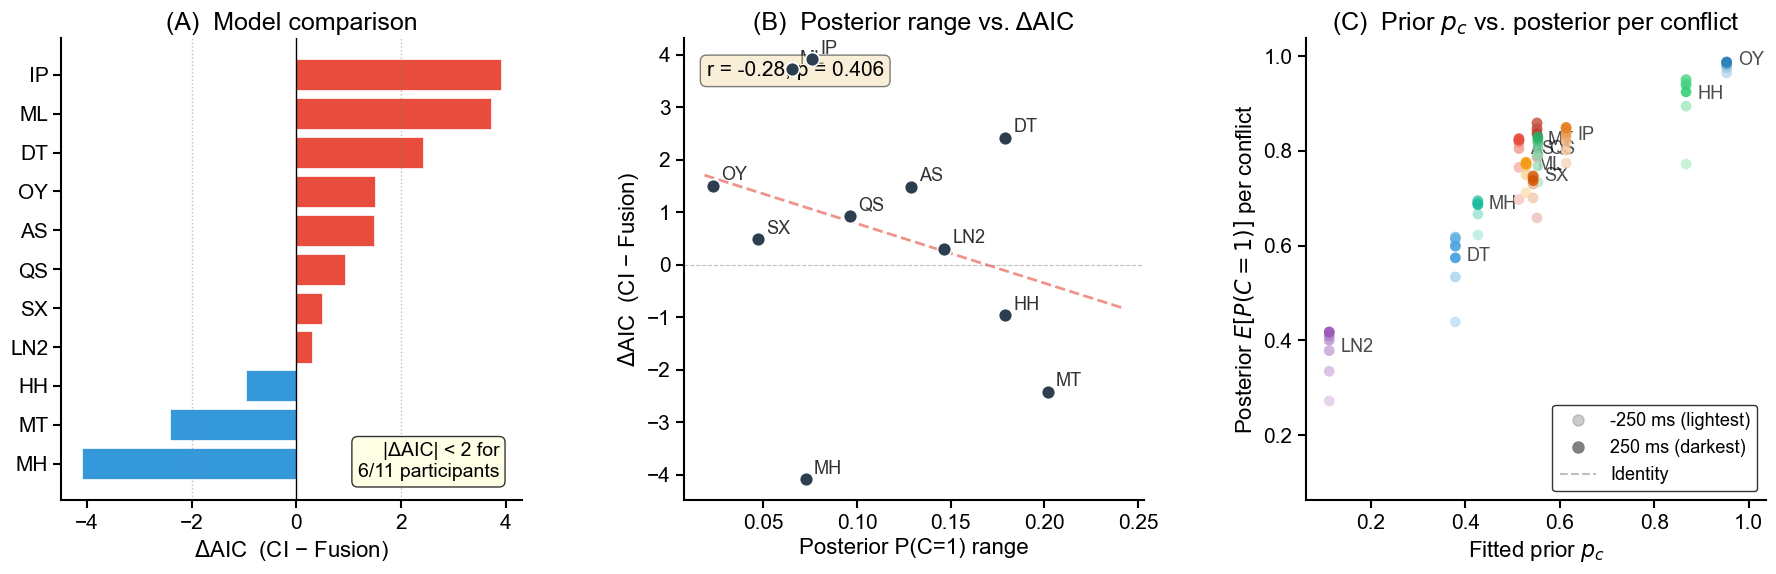

Figure saved: comprehensive_CI_vs_fusion.pdf/.png


In [41]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE: 3-panel analysis  (A-C)
# ══════════════════════════════════════════════════════════════════════════════
FS = 16

fig, (ax_A, ax_B, ax_C) = plt.subplots(1, 3, figsize=(22, 6))
plt.subplots_adjust(wspace=0.35)

# ── (A) ΔAIC bar chart per participant, sorted ───────────────────────────────
df_aic_sorted = df_scatter.sort_values('delta_AIC')
colors_A = ['#e74c3c' if v > 0 else '#3498db' for v in df_aic_sorted['delta_AIC']]
ax_A.barh(range(len(df_aic_sorted)), df_aic_sorted['delta_AIC'],
          color=colors_A, edgecolor='white', linewidth=0.5)
ax_A.set_yticks(range(len(df_aic_sorted)))
ax_A.set_yticklabels(df_aic_sorted['participant'], fontsize=FS)
ax_A.axvline(0, color='black', lw=1)
ax_A.axvline(2, color='gray', ls=':', lw=1, alpha=0.5)
ax_A.axvline(-2, color='gray', ls=':', lw=1, alpha=0.5)
ax_A.set_xlabel(r'$\Delta$AIC  (CI − Fusion)', fontsize=FS)
ax_A.set_title('(A)  Model comparison', fontsize=FS + 2)
ax_A.tick_params(labelsize=FS - 1)
ax_A.text(0.95, 0.05, f'|ΔAIC| < 2 for\n{(df_scatter["delta_AIC"].abs() < 2).sum()}/{len(df_scatter)} participants',
          transform=ax_A.transAxes, fontsize=FS - 2, ha='right',
          bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax_A.spines['top'].set_visible(False)
ax_A.spines['right'].set_visible(False)

# ── (B) Posterior range vs ΔAIC scatter ──────────────────────────────────────
ax_B.scatter(df_scatter['mean_range'], df_scatter['delta_AIC'],
             s=100, c='#2c3e50', edgecolors='white', linewidths=1.2, zorder=5)
for _, row in df_scatter.iterrows():
    ax_B.annotate(row['participant'], (row['mean_range'], row['delta_AIC']),
                  textcoords='offset points', xytext=(6, 4), fontsize=FS - 3, alpha=0.8)
if len(df_scatter) > 2:
    slope, intercept = np.polyfit(df_scatter['mean_range'], df_scatter['delta_AIC'], 1)
    x_fit = np.linspace(df_scatter['mean_range'].min() * 0.8,
                        df_scatter['mean_range'].max() * 1.2, 100)
    ax_B.plot(x_fit, slope * x_fit + intercept, '--', color='#e74c3c', lw=2, alpha=0.6)
r_val, p_val = stats.pearsonr(df_scatter['mean_range'], df_scatter['delta_AIC'])
ax_B.text(0.05, 0.95, f'r = {r_val:.2f}, p = {p_val:.3f}',
          transform=ax_B.transAxes, fontsize=FS - 1, va='top',
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax_B.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax_B.set_xlabel('Posterior P(C=1) range', fontsize=FS)
ax_B.set_ylabel(r'$\Delta$AIC  (CI − Fusion)', fontsize=FS)
ax_B.set_title('(B)  Posterior range vs. ΔAIC', fontsize=FS + 2)
ax_B.tick_params(labelsize=FS - 1)
ax_B.spines['top'].set_visible(False)
ax_B.spines['right'].set_visible(False)

# ── (C) Prior p_c vs posterior per conflict (light→dark = low→high |conflict|)
from matplotlib.colors import to_rgba
import matplotlib.lines as mlines

conflicts_sorted = sorted(df_post['conflict_ms'].unique())
n_conflicts = len(conflicts_sorted)

base_hues = [
    '#e74c3c', '#3498db', '#2ecc71', '#e67e22', '#9b59b6',
    '#1abc9c', '#f39c12', '#c0392b', '#2980b9', '#27ae60',
    '#d35400', '#8e44ad',
]

all_post_vals = []
for pid in pids_to_analyse:
    sub = df_post[df_post['participantID'] == pid]
    if sub.empty:
        continue
    p_c = df_scatter.loc[df_scatter['participant'] == participant_label(pid), 'p_c_prior']
    if p_c.empty:
        continue
    p_c_val = p_c.values[0]

    pid_idx = pids_to_analyse.index(pid) % len(base_hues)
    base_rgb = to_rgba(base_hues[pid_idx])[:3]

    avg_post = sub.groupby('conflict_ms')['mean_posterior'].mean()

    for j, c_ms in enumerate(conflicts_sorted):
        if c_ms not in avg_post.index:
            continue
        shade = 0.3 + 0.7 * (j / max(n_conflicts - 1, 1))
        color = tuple(ch * shade + (1 - shade) * 1.0 for ch in base_rgb)
        ax_C.scatter(p_c_val, avg_post[c_ms], s=60, color=color,
                     edgecolors='none', zorder=5, alpha=0.85)
        all_post_vals.append(avg_post[c_ms])

    ax_C.annotate(participant_label(pid), (p_c_val, avg_post.mean()),
                  textcoords='offset points', xytext=(8, 0),
                  fontsize=FS - 3, alpha=0.7)

lims = [min(df_scatter['p_c_prior'].min(), min(all_post_vals)) - 0.05,
        max(df_scatter['p_c_prior'].max(), max(all_post_vals)) + 0.05]
#ax_C.plot(lims, lims, '--', color='gray', lw=1.5, alpha=0.5, label='Identity (no updating)')
ax_C.set_xlim(lims)
ax_C.set_ylim(lims)
ax_C.set_xlabel(r'Fitted prior $p_c$', fontsize=FS)
ax_C.set_ylabel(r'Posterior $E[P(C{=}1)]$ per conflict', fontsize=FS)
ax_C.set_title(r'(C)  Prior $p_c$ vs. posterior per conflict', fontsize=FS + 2)

light_dot = mlines.Line2D([], [], marker='o', color='gray', alpha=0.4,
                           markersize=8, linestyle='None', label=f'{conflicts_sorted[0]} ms (lightest)')
dark_dot = mlines.Line2D([], [], marker='o', color='gray', alpha=1.0,
                          markersize=8, linestyle='None', label=f'{conflicts_sorted[-1]} ms (darkest)')
id_line = mlines.Line2D([], [], color='gray', ls='--', lw=1.5, alpha=0.5, label='Identity')
ax_C.legend(handles=[light_dot, dark_dot, id_line], fontsize=FS - 3, loc='lower right')
ax_C.tick_params(labelsize=FS - 1)
ax_C.spines['top'].set_visible(False)
ax_C.spines['right'].set_visible(False)

plt.savefig('comprehensive_CI_vs_fusion.pdf', bbox_inches='tight')
plt.savefig('comprehensive_CI_vs_fusion.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure saved: comprehensive_CI_vs_fusion.pdf/.png")

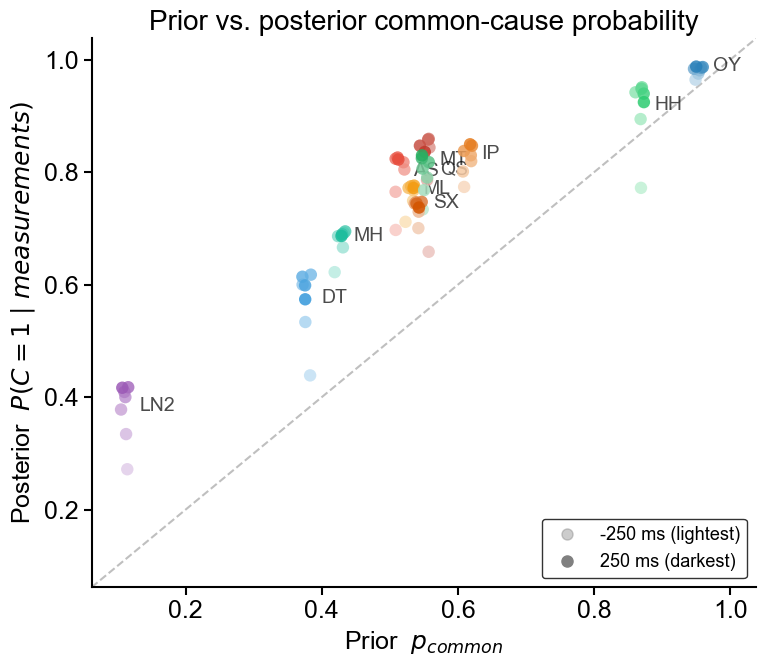

Figure saved: prior_vs_posterior_per_conflict.pdf/.png


In [42]:
# ── Standalone figure: Prior p_c vs posterior per conflict ────────────────────
from matplotlib.colors import to_rgba
import matplotlib.lines as mlines

fig_C, ax = plt.subplots(figsize=(8, 7))

conflicts_sorted = sorted(df_post['conflict_ms'].unique())
n_conflicts = len(conflicts_sorted)

base_hues = [
    '#e74c3c', '#3498db', '#2ecc71', '#e67e22', '#9b59b6',
    '#1abc9c', '#f39c12', '#c0392b', '#2980b9', '#27ae60',
    '#d35400', '#8e44ad',
]

all_post_vals = []
for pid in pids_to_analyse:
    sub = df_post[df_post['participantID'] == pid]
    if sub.empty:
        continue
    p_c = df_scatter.loc[df_scatter['participant'] == participant_label(pid), 'p_c_prior']
    if p_c.empty:
        continue
    p_c_val = p_c.values[0]

    pid_idx = pids_to_analyse.index(pid) % len(base_hues)
    base_rgb = to_rgba(base_hues[pid_idx])[:3]

    avg_post = sub.groupby('conflict_ms')['mean_posterior'].mean()

    for j, c_ms in enumerate(conflicts_sorted):
        if c_ms not in avg_post.index:
            continue
        shade = 0.3 + 0.7 * (j / max(n_conflicts - 1, 1))
        color = tuple(ch * shade + (1 - shade) * 1.0 for ch in base_rgb)
        jitter = rng.uniform(-0.008, 0.008)
        ax.scatter(p_c_val + jitter, avg_post[c_ms], s=80, color=color,
                   edgecolors='none', zorder=5, alpha=0.85)
        all_post_vals.append(avg_post[c_ms])

    ax.annotate(participant_label(pid), (p_c_val, avg_post.mean()),
                textcoords='offset points', xytext=(10, 0),
                fontsize=14, alpha=0.7)

lims = [min(df_scatter['p_c_prior'].min(), min(all_post_vals)) - 0.05,
        max(df_scatter['p_c_prior'].max(), max(all_post_vals)) + 0.05]
ax.plot(lims, lims, '--', color='gray', lw=1.5, alpha=0.5)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Prior  $p_{common}$')
ax.set_ylabel(r'Posterior  $P(C{=}1 \mid measurements)$')
ax.set_title(r'Prior vs. posterior common-cause probability')

light_dot = mlines.Line2D([], [], marker='o', color='gray', alpha=0.4,
                           markersize=8, linestyle='None', label=f'{conflicts_sorted[0]} ms (lightest)')
dark_dot = mlines.Line2D([], [], marker='o', color='gray', alpha=1.0,
                          markersize=8, linestyle='None', label=f'{conflicts_sorted[-1]} ms (darkest)')

#id_line = mlines.Line2D([], [], color='gray', ls='--', lw=1.5, alpha=0.5 )
ax.legend(handles=[light_dot, dark_dot], fontsize=13, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('prior_vs_posterior_per_conflict.pdf', bbox_inches='tight')
plt.savefig('prior_vs_posterior_per_conflict.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure saved: prior_vs_posterior_per_conflict.pdf/.png")

## Within-Subject One-Sample t-Test: Per-Conflict Posterior vs. Participant Mean

For each conflict level, compute each participant's **deviation** from their own mean posterior (averaged across conflicts and noise levels). Then run a one-sample t-test on those deviations across participants:

- **H₀**: mean deviation = 0 (this conflict level is not systematically different from each participant's own baseline)
- **N** = number of participants contributing to each conflict × noise cell
- Results are plotted as significance markers on the `prior_vs_posterior_per_conflict` figure.

One-sample t-test: deviation of posterior P(C=1) from participant mean
H₀: mean deviation = 0   (FDR-corrected across conflict levels, per noise)

  Low noise:
      Conflict     N    Mean dev        SD        t     p_raw     p_FDR   sig
        -250 ms    11     -0.1252    0.0895   -4.641    0.0009    0.0013     *
        -170 ms    11     -0.0317    0.0223   -4.707    0.0008    0.0013     *
         -80 ms    11     +0.0186    0.0166   +3.702    0.0041    0.0044     *
           0 ms    11     +0.0345    0.0223   +5.124    0.0004    0.0010     *
          80 ms    11     +0.0391    0.0203   +6.387    0.0001    0.0003     *
         170 ms    11     +0.0355    0.0176   +6.688    0.0001    0.0003     *
         250 ms    11     +0.0261    0.0236   +3.663    0.0044    0.0044     *

  High noise:
      Conflict     N    Mean dev        SD        t     p_raw     p_FDR   sig
        -250 ms    11     -0.0362    0.0342   -3.510    0.0056    0.0395     *
        -170 ms    11     -0.0100    

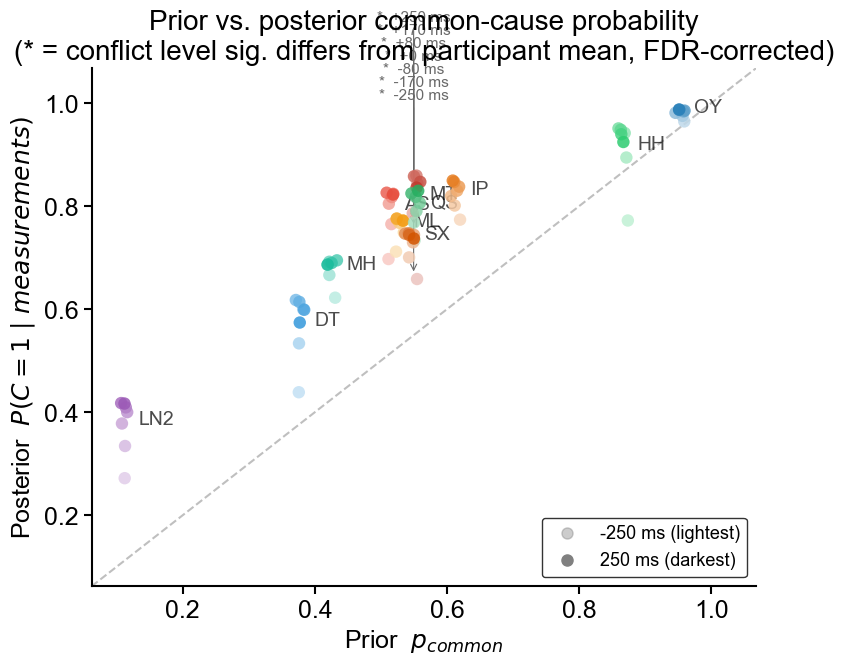

Figure saved: prior_vs_posterior_per_conflict_sig.pdf/.png


In [43]:
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests

# ── Step 1: participant mean posterior (collapsed across noise & conflict) ─────
pid_mean_post = (
    df_post.groupby('participantID')['mean_posterior']
    .mean()
    .rename('grand_mean')
)

# ── Step 2: deviations per participant × conflict × noise ─────────────────────
df_dev = df_post.copy()
df_dev = df_dev.join(pid_mean_post, on='participantID')
df_dev['deviation'] = df_dev['mean_posterior'] - df_dev['grand_mean']

# ── Step 3: one-sample t-test per conflict × noise level ──────────────────────
print("=" * 80)
print("One-sample t-test: deviation of posterior P(C=1) from participant mean")
print("H₀: mean deviation = 0   (FDR-corrected across conflict levels, per noise)")
print("=" * 80)

sig_results = {}   # key: (noise, conflict_ms) → p_corrected

for noise in sorted(df_dev['audioNoise'].unique()):
    sub = df_dev[df_dev['audioNoise'] == noise]
    conflicts_sorted = sorted(sub['conflict_ms'].unique())

    raw_ps, ts, ns, means, sds = [], [], [], [], []
    for c_ms in conflicts_sorted:
        devs = sub[sub['conflict_ms'] == c_ms]['deviation'].dropna().values
        t, p = ttest_1samp(devs, popmean=0)
        raw_ps.append(p)
        ts.append(t)
        ns.append(len(devs))
        means.append(devs.mean())
        sds.append(devs.std(ddof=1))

    # FDR correction (Benjamini-Hochberg) across the conflict levels
    reject, p_corr, _, _ = multipletests(raw_ps, method='fdr_bh')

    print(f"\n  {noise_labels[noise]}:")
    print(f"  {'Conflict':>12}  {'N':>4}  {'Mean dev':>10}  {'SD':>8}  "
          f"{'t':>7}  {'p_raw':>8}  {'p_FDR':>8}  {'sig':>4}")
    for c_ms, n, m, s, t, p_r, p_q, rej in zip(
            conflicts_sorted, ns, means, sds, ts, raw_ps, p_corr, reject):
        star = '*' if rej else ''
        print(f"  {c_ms:>10} ms  {n:>4}  {m:>+10.4f}  {s:>8.4f}  "
              f"{t:>+7.3f}  {p_r:>8.4f}  {p_q:>8.4f}  {star:>4}")
        sig_results[(noise, c_ms)] = {'p_fdr': p_q, 'sig': rej, 't': t, 'mean_dev': m}

# ── Step 4: re-draw prior_vs_posterior_per_conflict with significance markers ──
from matplotlib.colors import to_rgba
import matplotlib.lines as mlines

fig_C2, ax2 = plt.subplots(figsize=(8, 7))

conflicts_sorted = sorted(df_post['conflict_ms'].unique())
n_conflicts = len(conflicts_sorted)
base_hues = [
    '#e74c3c', '#3498db', '#2ecc71', '#e67e22', '#9b59b6',
    '#1abc9c', '#f39c12', '#c0392b', '#2980b9', '#27ae60',
    '#d35400', '#8e44ad',
]

all_post_vals2 = []
for pid in pids_to_analyse:
    sub = df_post[df_post['participantID'] == pid]
    if sub.empty:
        continue
    p_c = df_scatter.loc[df_scatter['participant'] == participant_label(pid), 'p_c_prior']
    if p_c.empty:
        continue
    p_c_val = p_c.values[0]

    pid_idx = pids_to_analyse.index(pid) % len(base_hues)
    base_rgb = to_rgba(base_hues[pid_idx])[:3]
    avg_post = sub.groupby('conflict_ms')['mean_posterior'].mean()

    for j, c_ms in enumerate(conflicts_sorted):
        if c_ms not in avg_post.index:
            continue
        shade = 0.3 + 0.7 * (j / max(n_conflicts - 1, 1))
        color = tuple(ch * shade + (1 - shade) * 1.0 for ch in base_rgb)
        jitter = rng.uniform(-0.008, 0.008)
        ax2.scatter(p_c_val + jitter, avg_post[c_ms], s=80, color=color,
                    edgecolors='none', zorder=5, alpha=0.85)
        all_post_vals2.append(avg_post[c_ms])

    ax2.annotate(participant_label(pid), (p_c_val, avg_post.mean()),
                 textcoords='offset points', xytext=(10, 0),
                 fontsize=14, alpha=0.7)

# ── Significance band: for each conflict level that is sig (collapsed across
#    noise), draw a horizontal line at the group mean posterior ─────────────────
y_annot = max(all_post_vals2) + 0.02
for j, c_ms in enumerate(conflicts_sorted):
    # Check if significant in either noise condition
    sig_any = any(sig_results.get((noise, c_ms), {}).get('sig', False)
                  for noise in sorted(df_post['audioNoise'].unique()))
    if not sig_any:
        continue

    # Group mean posterior at this conflict (avg across noise & participants)
    gm = df_post[df_post['conflict_ms'] == c_ms]['mean_posterior'].mean()
    shade = 0.3 + 0.7 * (j / max(n_conflicts - 1, 1))
    # Collect x positions of all participants for this conflict
    x_positions = []
    for pid in pids_to_analyse:
        p_c_row = df_scatter.loc[df_scatter['participant'] == participant_label(pid), 'p_c_prior']
        if not p_c_row.empty:
            x_positions.append(p_c_row.values[0])
    if x_positions:
        ax2.annotate(
            f'*  {c_ms:+.0f} ms',
            xy=(np.mean(x_positions), gm),
            xytext=(np.mean(x_positions), y_annot),
            fontsize=11, color='dimgray', ha='center',
            arrowprops=dict(arrowstyle='->', color='dimgray', lw=0.8),
        )
        y_annot += 0.025

lims2 = [min(df_scatter['p_c_prior'].min(), min(all_post_vals2)) - 0.05,
         max(df_scatter['p_c_prior'].max(), max(all_post_vals2)) + 0.08]
ax2.plot(lims2, lims2, '--', color='gray', lw=1.5, alpha=0.5)
ax2.set_xlim(lims2); ax2.set_ylim(lims2)
ax2.set_xlabel(r'Prior  $p_{common}$')
ax2.set_ylabel(r'Posterior  $P(C{=}1 \mid measurements)$')
ax2.set_title(r'Prior vs. posterior common-cause probability' + '\n(* = conflict level sig. differs from participant mean, FDR-corrected)')

light_dot = mlines.Line2D([], [], marker='o', color='gray', alpha=0.4,
                           markersize=8, linestyle='None',
                           label=f'{conflicts_sorted[0]} ms (lightest)')
dark_dot  = mlines.Line2D([], [], marker='o', color='gray', alpha=1.0,
                           markersize=8, linestyle='None',
                           label=f'{conflicts_sorted[-1]} ms (darkest)')
ax2.legend(handles=[light_dot, dark_dot], fontsize=13, loc='lower right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('prior_vs_posterior_per_conflict_sig.pdf', bbox_inches='tight')
plt.savefig('prior_vs_posterior_per_conflict_sig.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure saved: prior_vs_posterior_per_conflict_sig.pdf/.png")

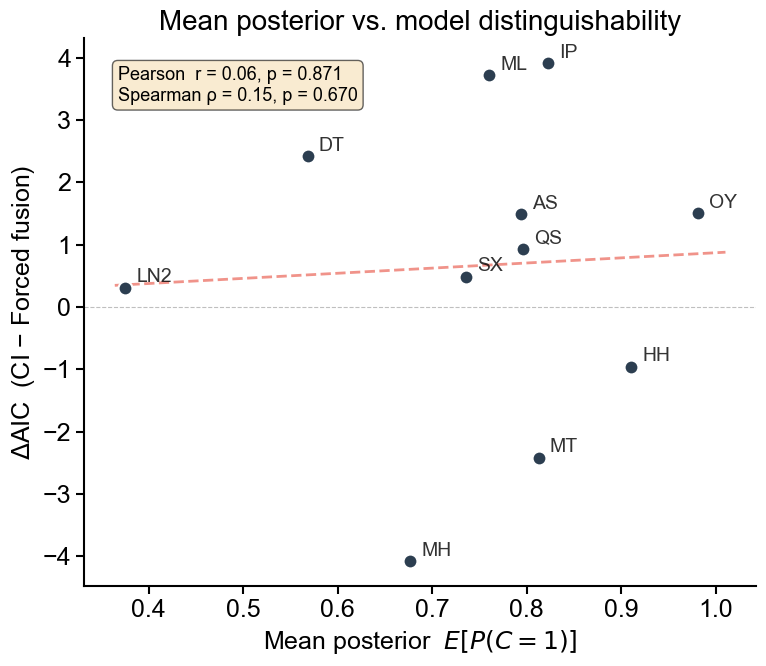

Figure saved: mean_posterior_vs_deltaAIC.pdf/.png


In [44]:
# ── Standalone figure: Mean posterior P(C=1) vs ΔAIC ─────────────────────────
fig_D, ax = plt.subplots(figsize=(8, 7))

ax.scatter(df_scatter['mean_posterior'], df_scatter['delta_AIC'],
           s=100, c='#2c3e50', edgecolors='white', linewidths=1.5, zorder=5)

for _, row in df_scatter.iterrows():
    ax.annotate(row['participant'], (row['mean_posterior'], row['delta_AIC']),
                textcoords='offset points', xytext=(8, 4), fontsize=14, alpha=0.8)

if len(df_scatter) > 2:
    slope, intercept = np.polyfit(df_scatter['mean_posterior'], df_scatter['delta_AIC'], 1)
    x_fit = np.linspace(df_scatter['mean_posterior'].min() * 0.97,
                        df_scatter['mean_posterior'].max() * 1.03, 100)
    ax.plot(x_fit, slope * x_fit + intercept, '--', color='#e74c3c', lw=2, alpha=0.6)

r_val, p_val = stats.pearsonr(df_scatter['mean_posterior'], df_scatter['delta_AIC'])
rho_val, p_rho = stats.spearmanr(df_scatter['mean_posterior'], df_scatter['delta_AIC'])
ax.text(0.05, 0.95,
        f'Pearson  r = {r_val:.2f}, p = {p_val:.3f}\nSpearman ρ = {rho_val:.2f}, p = {p_rho:.3f}',
        transform=ax.transAxes, fontsize=13, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)

ax.set_xlabel(r'Mean posterior  $E[P(C{=}1)]$')
ax.set_ylabel(r'$\Delta$AIC  (CI − Forced fusion)')
ax.set_title('Mean posterior vs. model distinguishability')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('mean_posterior_vs_deltaAIC.pdf', bbox_inches='tight')
plt.savefig('mean_posterior_vs_deltaAIC.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure saved: mean_posterior_vs_deltaAIC.pdf/.png")